In [1]:
import wfdb     # import wfdb         # [필수] 피지오넷(.dat) 파일을 읽어오는 전용 해독기
import os       # import os         # [기초] 폴더 경로를 관리하는 관리자
import glob     # import golb         # [검색] 폴더 내 파일들을 싹 긁어모으는 탐지견
import pandas as pd # import pandas as pd     # [분석] 데이터를 엑셀 표처럼 다루는 도구
import numpy as np   #import numpy as np     # [계산] 수학적 연산을 처리하는 계산기
import matplotlib.pyplot as plt    #import matplotilb.pyp as plt # [시각화] 그래프를 그리는 도구
# wfdb로 꺼내고 ,pandas에 담고,mqtplotlib 으로 전공책 파형을 확인한다
#wfdb로 꺼내고, pandas에 담고, matplotlib으로 전공책 파형을 확인한다!
#데이터 불러오기!!!!!!!!!!!!

In [2]:
# 경로 불러오기
# 1. 원본 데이터가 들어있는 폴더 경로 (r을 붙여야 경로 오류가 안 납니다)
base_path = r"./data/CEMG_Data/surface-electromyographic-signals-collected-during-long-lasting-ground-walking-of-young-able-bodied-subjects-1.0.1"
           # 경로 ----> 결로복사 인 그럼 에러  해걸하고 가야됨 안그럼 뭉텅이로 터짐 
# 2. 해당 폴더에서 .dat 파일들만 찾아서 리스트로 만듭니다.
#?------- 원본파일에 had 파일고 dat 파일 섞여있음 그거 구분
file_list = sorted(glob.glob(os.path.join(base_path, "*.dat")))
# filb list = sorted(glob.glob(os.path.join(base_path."*dat")))
print(f"✅ 총 {len(file_list)}명의 파일을 찾았습니다.")     #----> 피 실험자 파악(연구 논문에 나온 연구대상)

✅ 총 31명의 파일을 찾았습니다.


In [3]:
# 잘 나오는지 확인위해서 1명 만 정제안된 데이터 갖고오기
# 1. 첫 번째 파일의 이름을 가져옵니다 (확장자 .dat 제외)
# 파일 이름 가져오기
#sample_record_name = file_list[0]. replace('.dat', '')
sample_record_name = file_list[0].replace('.dat', '')

# 2. wfdb.rdrecord: 원본 데이터를 가공 없이 통째로 '객체'로 불러오기
record = wfdb.rdrecord(sample_record_name)
# record= wfed.rdrecord(sample_record_name)
# 3. [검수] 이 파일 안에 어떤 근육들이 들어있는지 '변수명'만 먼저 확인
# print (f"

print(f"📍 대상 파일: {os.path.basename(sample_record_name)}")
print(f"💪 원본에 포함된 근육(채널) 이름들: \n{record.sig_name}")

📍 대상 파일: S01
💪 원본에 포함된 근육(채널) 이름들: 
['baso LT FOOT', 'gonio RT HIP', 'semg LT TIB.A', 'semg LT LAT.G', 'semg LT REC.F', 'semg LT HAM', 'semg LT LAT.V', 'baso RT FOOT', 'gonio RT KNEE', 'semg RT TIB.A', 'semg RT LAT.G', 'semg RT REC.F', 'semg RT HAM', 'semg RT LAT.V']


In [4]:
# 규격화
#데이터 통합 (Integration): 31개로 쪼개진 개별 파일을 하나의 바구니에 담아, 전체 데이터를 한 번에 요리하기 위해서

#비교 가능성 (Comparability): 모든 피험자의 근육 순서와 이름을 똑같이 맞춰야, "A 환자와 B 환자의 외측광근 차이"**를 통계적으로 계산

#자동화 (Automation): 규격이 같아야만 수백만 줄의 데이터에 노이즈 제거 필터를 단 한 줄의 코드로 동시에 적용


#규격화 함수

#wfdb.rdrecord(): 31명의 제각각인 원본 파일(.dat)을 파이썬이 읽을 수 있는 공통 객체로 변환
#pd.DataFrame(..., columns=record.sig_name): 날것의 숫자들에 공통된 근육 이름표를 붙여서 똑같은 모양의 표로 만들기

#pd.concat(..., ignore_index=True): 규격이 맞춰진 31개의 표를 하나의 거대한 통합 문서
# --------------------------------------------------------------------------
# [Step 1-3] 31명 전체 피험자의 원본 데이터를 하나의 거대한 데이터프레임으로 통합
# --------------------------------------------------------------------------

# 1. 31명 개별 데이터를 임시로 저장할 빈 리스트(바구니)를 생성합니다.
# 리스트에 담아두었다가 한꺼번에 합치는 것이 메모리 효율상 훨씬 빠릅니다.
all_raw_data = []

#all_row_data = [] 
print("🚀 31명 전수 조사 시작 (원본 데이터 수집 중...)")

# file_list에 담긴 31개의 파일 경로를 하나씩 꺼내서 반복문을 돌립니다.
#---->31명의 차트가 든 가방(file_list)에서 차트 뭉치를 하나씩(file_path) 꺼내겠다"
#----?--->컴퓨터는 31명을 한꺼번에 인지 불가 첫 번째 사람 처리 끝 -> 두 번째 사람 시작' 이런 식.--->순차적을로 읽어온다


for file_path in file_list:
    
    # [A] 파일 경로에서 확장자(.dat)를 제거하여 wfdb가 읽을 수 있는 이름으로 만들기
    record_name = file_path.replace('.dat', '')
    
    # [B] 경로에서 순수 파일명(예: S01, S02...)만 추출하여 피험자 식별자로 사용
    subject_id = os.path.basename(record_name)
    
    try:
        # [C] wfdb.rdrecord: 피지오넷 원본 신호(p_signal)와 정보들을 객체 형태로 로드
        # 가공(필터링)하지 않은 '날것(Raw)' 그대로의 상태암!
        record = wfdb.rdrecord(record_name)
        
        # [D] record.p_signal(수치 데이터)을 판다스 데이터프레임(표)으로 변환!
        # columns=record.sig_name을 통해 아까 확인한 14개 근육/센서 이름을 열 제목 으로 정함
        temp_df = pd.DataFrame(record.p_signal, columns=record.sig_name)
        #p_signal)을 엑셀 표로 옮겨 적어   
        #열 이름은 아까 확인한 근육 이름들
        
        # [E] 데이터 구분을 위한 '라벨링' 작업
        # 31명을 합치면 누가 누군지 알 수 없으므로, 'Subject' 열을 만들어 피험자 ID를 기록
        temp_df['Subject'] = subject_id
        
        # [F] 준비된 바구니(리스트)에 현재 피험자의 표를 추가
        all_raw_data.append(temp_df)
        
        # 진행 상황을 실시간으로 출력하여 작업 중임을 확인(---> 실무에서 씀)
        print(f"✅ {subject_id} 완료", end=' | ')
        
    except Exception as e:
        # 파일이 깨졌거나 경로 오류가 발생할 경우를 대비한 예외 처리
        print(f"\n❌ {subject_id} 로드 중 에러 발생: {e}")

# --------------------------------------------------------------------------
# 2. 리스트에 모인 31개의 데이터프레임을 위아래로 길게 이어 붙입니다 (Concatenation)
# --------------------------------------------------------------------------
# ignore_index=True: 개별 파일의 인덱스(0, 1, 2...)를 무시하고 전체 0번부터 새로 번호를 매깁니다.
df_31_raw = pd.concat(all_raw_data, ignore_index=True)

# 최종 로드 결과 보고
print(f"\n\n🏆 31명 원본 로드 완료!")
print(f"📊 전체 데이터 규모: {len(df_31_raw):,} 행 (Rows) x {df_31_raw.shape[1]} 열 (Columns)")
print(f"👥 피험자 명단: {df_31_raw['Subject'].unique()}")

🚀 31명 전수 조사 시작 (원본 데이터 수집 중...)
✅ S01 완료 | ✅ S10 완료 | ✅ S11 완료 | ✅ S12 완료 | ✅ S13 완료 | ✅ S14 완료 | ✅ S15 완료 | ✅ S16 완료 | ✅ S17 완료 | ✅ S18 완료 | ✅ S19 완료 | ✅ S2 완료 | ✅ S20 완료 | ✅ S21 완료 | ✅ S22 완료 | ✅ S23 완료 | ✅ S24 완료 | ✅ S25 완료 | ✅ S26 완료 | ✅ S27 완료 | ✅ S28 완료 | ✅ S29 완료 | ✅ S3 완료 | ✅ S30 완료 | ✅ S31 완료 | ✅ S4 완료 | ✅ S5 완료 | ✅ S6 완료 | ✅ S7 완료 | ✅ S8 완료 | ✅ S9 완료 | 

🏆 31명 원본 로드 완료!
📊 전체 데이터 규모: 15,990,351 행 (Rows) x 16 열 (Columns)
👥 피험자 명단: ['S01' 'S10' 'S11' 'S12' 'S13' 'S14' 'S15' 'S16' 'S17' 'S18' 'S19' 'S2'
 'S20' 'S21' 'S22' 'S23' 'S24' 'S25' 'S26' 'S27' 'S28' 'S29' 'S3' 'S30'
 'S31' 'S4' 'S5' 'S6' 'S7' 'S8' 'S9']


In [5]:
# 1. 통합 데이터(df_31_raw)에서 S01 환자 차트만 쏙 빼기
#데이터의 타겟팅 (Targeting)
# df_31_raw에는 31명의 데이터가 수직으로 길게 붙어 있음

#목적: "그중에서 S01이라는 이름표가 붙은 행들만 따로 복사해와!"라고 명령
s01_df = df_31_raw[df_31_raw['Subject'] == 'S01'].copy()

# 2. 그중에서 '좌측 전경골근' 데이터만 숫자로 변환
#필요한 정보만 추출
#많은 정보 중 분석할 '좌측 전경골근(semg LT TIB.A)' 신호만 뽑기
#왜?---->불필요한 데이터를 제외  ---->순수하게 근육 신호(숫자 배열)만 가지고 필터링
raw_emg = s01_df['semg LT TIB.A'].values

# 3. 샘플링 속도 설정 (피지오넷 보행 데이터는 보통 1000Hz)
#왜 ?------>신호 복원: 500Hz짜리 근육 신호를 제대로 보려면 2배인 1,000은 찍어야 험

#데이터 규격: 지금 내가 다루는 파일 자체가 1,000Hz로 만들어진 파일

#결론: 그래서 우리는 fs = 1000이라는 기준점을 세워놓고 "이 속도에 맞춰서 20Hz 이하(흔들림)를 깎아내라"고 시키는 것
fs = 1000

In [6]:
from scipy.signal import butter, filtfilt

# [1단계] 잡음 제거: 20~450Hz 사이의 깨끗한 신호만 남기기

#butter & filtfilt (찌꺼기 걸러내기)

#설명: "20Hz 미만의 흔들림 잡음은 버리고, 진짜 근육 신호만 통과시키는 정밀 채망을 만들어 거르는 작업

#목적: 환자가 움직일 때 전선이 출렁거려서 생기는 가짜 신호를 삭제!
# b, a = butter(4,[20 ,450], btype = 'babdoress', fs=fs)
# filtered_eng = filtfile(b,a, raw_eng)

b, a = butter(4, [20, 450], btype='bandpass', fs=fs)
filtered_emg = filtfilt(b, a, raw_emg)

# [2단계] 양수화: 위아래로 진동하는 신호를 전부 (+)로 뒤집기 (절댓값)
#np.abs    위아래(+/-)로 진동하는 신호에 절댓값을 씌워 모두 위(+) 방향으로 꺾어 올리는 작업"

rectified_emg = np.abs(filtered_emg)

# [3단계] 매끄럽게: 6Hz 저역통과 필터로 '외곽선(Envelope)' 만들기
#부드러운 곡선만 남기가
b_low, a_low = butter(4, 6, btype='low', fs=fs)
envelope_emg = filtfilt(b_low, a_low, rectified_emg)
#신호의 위치가 옆으로 밀리지 않게(왜곡 방지) 해서 정확한 수축 타이밍을 잡기 위해

#이 코드를 쓴 진짜이유
#--->잡음을 제거하고, 데이터 밀림 없이 매끈한 근수축 곡선을 추출하여 '언제, 얼마나' 힘을 썼는지 명확히 확인하는 것이 최종 목적
# 처음보는 함수 개념정리
#butter(N, Wn, btype, fs) : "필터 설계 전문가"
#결과값 (b, a): 설계된 필터의 수학적 계수  ---->데이터 거르기 위한 목적

#filtfilt(b, a, data) 
#	정밀 세척 (두 번 반복)	신호 밀림 없는 정확한 타이밍 확보

# 왜 두번반복 하나요?

#--->1.데이터를 왼쪽에서 오른쪽으로 훑으며 잡음을 거릅--->잡음은 0, 필터 계산 시간 이유로  1cm 정도 밀림
#두 번째 통과 역방향 
#밀려버린 데이터를 이번에는 거꾸로(오른쪽에서 왼쪽으로) 다시 한번 필터에 넣고 돌립
#파형이 다시 왼쪽으로 1cm 밀림 --> 다시 제자릴로 옴!!

C:\Users\smhrd1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\smhrd1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44163 (\N{HANGUL SYLLABLE GEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\smhrd1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\smhrd1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\smhrd1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(by

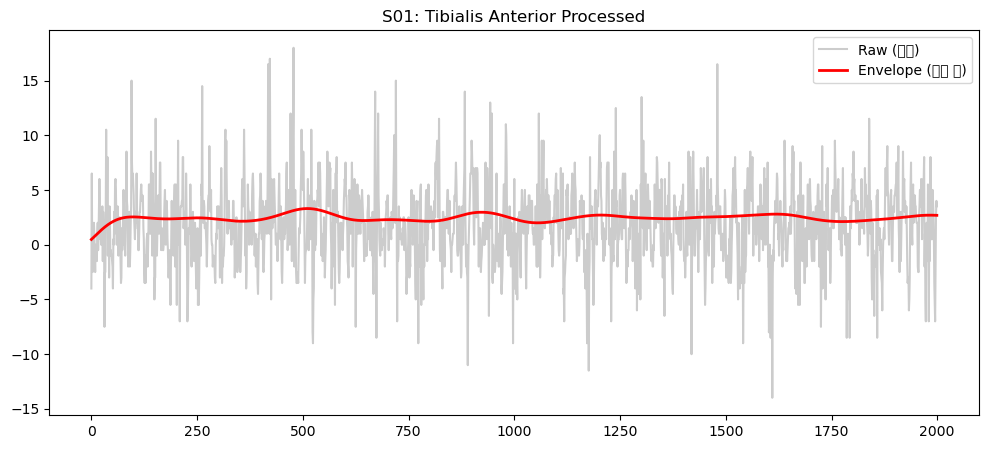

In [7]:
plt.figure(figsize=(12, 5))  #----> 이 사이즈로 그럴거야!

# 원본(회색)과 수술 후(빨간색) 비교
plt.plot(raw_emg[:2000], label='Raw (날것)', alpha=0.4, color='gray')   # 애 개 많이 봄
plt.plot(envelope_emg[:2000], label='Envelope (수술 후)', color='red', linewidth=2)  # 색깔은 빨강으로 할거고 길이는 2로 할거야

plt.title("S01: Tibialis Anterior Processed")  #타이틀 이름은 ("S01: Tibialis Anterior Processed") 이거
plt.legend()
plt.show() # 그래프 보여줘

In [8]:
# [셀 1: 분석 로직 설계] 
# 목적: 31명 대상자의 대용량 데이터를 동일한 알고리즘으로 처리하기 위해 로직을 '함수화'함

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt # 신호처리를 위한 필수 라이브러리 (Scipy) 호출

# import numpy as np
#import pandas as pd
#from scipy.signal import butter, filtfilt -
# 애내 왜 또 불러와요?---->파이썬의 관례이자 안전장치 
#독립성: 만약 맨 위에서만 import를 해두고 아래 셀에서 안 쓰면,
#나중에 이 셀만 복사해서 딴 데 썼을 때 "나 butter가 뭔지 몰라!" 하고 애러

def process_emg_signal(raw_data, fs=1000):
    """
    [EMG Envelope Extraction Pipeline]
    - 목적: raw 신호의 노이즈 제거 및 진폭 엔벨로프(Amplitude Envelope) 추출
    - 파라미터: fs(Sampling Frequency)는 데이터의 주기성을 계산하는 기준점임
    """
    
    # 1. Bandpass Filter 설계 (20-450Hz)
    # [butter]: 4차(4th order) 버터워스 필터 계수를 생성. 차수가 높을수록 차단 대역이 급격해짐
    # [[20, 450]]: 신호의 유효 주파수 대역만 남기고 저주파/고주파 노이즈를 동시 차단
    # [btype='bandpass']: 특정 주파수 사이만 통과시키는 필터 유형 설정
    b, a = butter(4, [20, 450], btype='bandpass', fs=fs)
    
    # [filtfilt]: 위상 지연(Phase Shift) 방지를 위한 'Zero-phase filtering' 수행
    # 일반 필터와 달리 데이터를 앞뒤로 두 번 통과시켜 시간축의 왜곡을 물리적으로 제거함
    filtered = filtfilt(b, a, raw_data)
    
    # 2. Full-wave Rectification (절댓값 처리)
    # [np.abs]: 교류(AC) 형태의 신호를 직류(DC) 형태처럼 분석하기 위해 모든 값을 양수로 변환
    # 신호의 전체 에너지 강도를 계산하기 위한 필수적인 비선형 변환 과정임
    rectified = np.abs(filtered)
    
    # 3. Low-pass Filter 설계 (6Hz)
    # [btype='low']: 고주파 성분을 제거하고 신호의 부드러운 '외곽선(Envelope)'만 추출
    b_low, a_low = butter(4, 6, btype='low', fs=fs)
    
    # [filtfilt]: 최종 엔벨로프 추출 시에도 시간 오차를 없애기 위해 왕복 필터링 적용
    envelope = filtfilt(b_low, a_low, rectified)
    
    # [return]: 처리된 최종 결과값을 메모리 상의 변수로 반환하여 다음 프로세스로 넘김
    return envelope 

print("✅ 분석 함수(세척기) 설계 완료! (기술 설계 주석 반영)")

✅ 분석 함수(세척기) 설계 완료! (기술 설계 주석 반영)


In [9]:
# [긴급 진단 셀]
print(f"1. 바구니의 첫 번째 항목 타입: {type(all_raw_data[0])}")

# 만약 데이터프레임이라면 컬럼명을 확인해야 함
if hasattr(all_raw_data[0], 'columns'):
    print(f"2. 데이터프레임 컬럼들: {all_raw_data[0].columns.tolist()}")
else:
    print(f"2. 데이터 내용 일부: {all_raw_data[0][:5]}") # 리스트라면 앞부분 5개만

1. 바구니의 첫 번째 항목 타입: <class 'pandas.core.frame.DataFrame'>
2. 데이터프레임 컬럼들: ['baso LT FOOT', 'gonio RT HIP', 'semg LT TIB.A', 'semg LT LAT.G', 'semg LT REC.F', 'semg LT HAM', 'semg LT LAT.V', 'baso RT FOOT', 'gonio RT KNEE', 'semg RT TIB.A', 'semg RT LAT.G', 'semg RT REC.F', 'semg RT HAM', 'semg RT LAT.V', 'Subject']


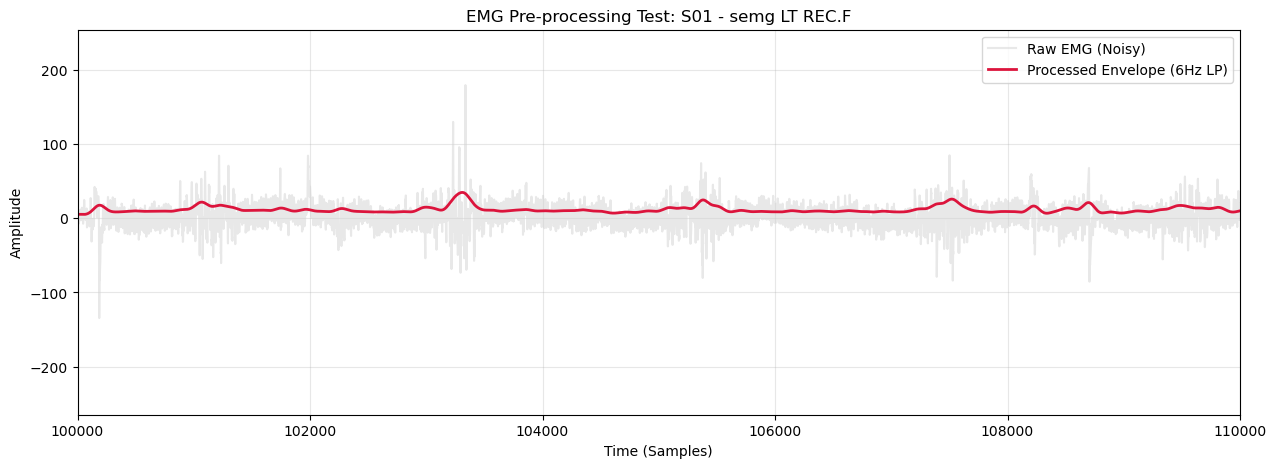

✅ 테스트 완료! 대상자: S01, 분석근육: semg LT REC.F
🧐 체크포인트: 빨간 선이 회색 노이즈의 '윗부분 테두리'를 부드럽게 감싸고 있나요?


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# [1. 방어 로직] subjects 리스트 자동 생성
# 이유: NameError 방지용. 위에서 실행 안 했어도 S01~S31까지 이름을 강제로 만들어줌
if 'subjects' not in locals():
    subjects = [f'S{i+1:02d}' for i in range(31)] 

# [셀 1-2: 함수 성능 검증 - Pilot Test]
# 목적: 31명을 다 돌리기 전, S01 데이터를 통해 필터 성능을 시각적으로 최종 확인

# 1. 테스트용 대상자 및 근육 선택
test_sub_idx = 0 # S01 (첫 번째 피험자 선택)
target_muscle = 'semg LT REC.F' # 좌측 대퇴직근 (보행 분석 핵심 타겟)

# 2. 데이터 추출 (리스트 -> 데이터프레임 -> 넘파이 배열)
# 문법: all_raw_data[idx] -> 리스트에서 특정 DF 추출
# 문법: .values -> 판다스 시리즈를 계산이 빠른 넘파이 배열로 변환
sample_df = all_raw_data[test_sub_idx]
raw_signal = sample_df[target_muscle].values

# 3. '세척기(함수)' 가동
# 이유: Raw EMG는 노이즈가 심해 바로 못 씀. 정류+저역통과필터(6Hz)로 '봉락선(Envelope)' 추출
processed_signal = process_emg_signal(raw_signal)

# 4. 비교 시각화 (Overlay 그래프)
# 문법: figsize=(15, 5) -> 가로로 길게 뽑아서 보행 주기를 디테일하게 관찰함
plt.figure(figsize=(15, 5))

# 원본 신호 (연한 회색 배경)
# 문법: alpha=0.5 -> 투명도를 줘서 배경처럼 깔아줌 (전처리 신호와 대비)
plt.plot(raw_signal, color='lightgray', alpha=0.5, label='Raw EMG (Noisy)')

# 전처리 신호 (진한 빨간색 강조)
# 문법: linewidth=2 -> 선 굵기를 키워 분석 결과인 '봉락선'이 잘 보이게 함
plt.plot(processed_signal, color='crimson', linewidth=2, label='Processed Envelope (6Hz LP)')

# 그래프 제목 및 라벨링
# 문법: f-string -> 변수(subjects, muscle)를 문자열 안에 동적으로 삽입
plt.title(f"EMG Pre-processing Test: {subjects[test_sub_idx]} - {target_muscle}")
plt.xlabel("Time (Samples)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right') # 범례 표시
plt.grid(True, alpha=0.3)     # 격자 추가 (수치 파악 용이)

# 특정 구간 확대해서 보기 (중요!)
# 이유: 전체 데이터를 다 띄우면 너무 뭉개져서 필터가 잘 됐는지 알 수 없음. 
# 10초 내외(약 10,000 샘플)만 잘라서 '빨간 선'의 밀착도를 확인하는 용도
plt.xlim(100000, 110000) 

plt.show()

# 최종 확인 메시지
print(f"✅ 테스트 완료! 대상자: {subjects[test_sub_idx]}, 분석근육: {target_muscle}")
print("🧐 체크포인트: 빨간 선이 회색 노이즈의 '윗부분 테두리'를 부드럽게 감싸고 있나요?")

In [11]:
# -------------------------------------------------------------------------
# [1단계] 어떤 근육을 전수 조사할지 결정 (수사 타겟 설정)
# -------------------------------------------------------------------------
target_muscle = 'semg LT REC.F' 
all_results = [] # 31명의 데이터를 담을 '증거 바구니' 초기화

# 🚀 이거 꼭 필요? -> [답변] 네! 대량의 데이터를 돌릴 땐 "지금 내가 뭘 하고 있는지" 
# 터미널에 찍어줘야 프로그램이 멈춘 건지 일하고 있는 건지 알 수 있어요. (심리적 안정제 ㅋㅋㅋ)
print(f"🚀 31명 대상자의 {target_muscle} 분석을 시작합니다...") 

# -------------------------------------------------------------------------
# [2단계] 31명 루프 돌리기 (전수조사 시작)
# -------------------------------------------------------------------------
for i, sub in enumerate(subjects): 
    try:
        # [데이터 추출] 전수조사 리스트에서 i번째 사람의 표를 꺼내서 특정 근육만 넘파이 배열로 변환
        current_df = all_raw_data[i]
        current_raw_signal = current_df[target_muscle].values
        
        # [전처리 가동] 피지오넷의 거친 야생 신호를 '완벽하게' 정제(Envelope)
        cleaned_envelope = process_emg_signal(current_raw_signal)
        
        # [결과 저장] 나중에 찾기 좋게 '딕셔너리'라는 이름표를 붙여서 바구니에 담기
        all_results.append({
            'subject_id': sub,
            'emg_envelope': cleaned_envelope,
            'muscle_name': target_muscle
        })
        
        # [실무 로그] 5명 단위로 진행 상황 보고 (현경님 분석: i+1이 5의 배수이거나 마지막 31번일 때)
        # % 5 == 0 : 5명마다 찍기 / (i+1) == 31 : 마지막 31명째에서 "끝났다!"라고 외치기 위함
        if (i+1) % 5 == 0 or (i+1) == 31:
            print(f"✅ {i+1}/31 완료...")

    except Exception as e:
        # ❌ 요거 나중에 분석 안 됨 표시하기 위해서 -> [답변] 아주 훌륭한 '방어적 코딩'입니다!
        # 31명 중 한 명이라도 에러 나면 전체가 멈추는데, 이걸 쓰면 에러 난 사람만 건너뛰고 계속 가니까요.
        print(f"❌ {sub} 분석 실패: {e}") 

# [마무리 멘트] 분석이 잘 되면 나오는 시원한 한마디!
print("\n✨ 31명 전처리 완료! 이제 'df_summary'를 다시 돌려서 진짜 숫자를 확인할 시간입니다.")

🚀 31명 대상자의 semg LT REC.F 분석을 시작합니다...
✅ 5/31 완료...
✅ 10/31 완료...
✅ 15/31 완료...
✅ 20/31 완료...
✅ 25/31 완료...
✅ 30/31 완료...
✅ 31/31 완료...

✨ 31명 전처리 완료! 이제 'df_summary'를 다시 돌려서 진짜 숫자를 확인할 시간입니다.


In [12]:
# -------------------------------------------------------------------------
# [수사 결과 요약] 31명의 개별 데이터를 하나의 '성적표'로 합치는 과정
# -------------------------------------------------------------------------
summary_list = [] 

for res in all_results:
    env_data = res['emg_envelope'] # 전처리 완료된 깨끗한 근육 신호 (빨간 선)
    
    summary_list.append({
        'Subject': res['subject_id'],
        'Muscle': res['muscle_name'],
        'Mean_Activity': np.mean(env_data), # [평균 근활성도] 전체적인 지구력/힘의 크기
        'Max_Burst': np.max(env_data),     # [최대 수축력] 순간적 폭발력 (에이스 선별 지표)
        'Std_Dev': np.std(env_data),       # [변동성] 움직임이 얼마나 일정한가 (낮을수록 안정적)
        'Samples': len(env_data)           # [데이터 검수] 0이거나 너무 작으면 데이터 불량! (중요)
    })

# [데이터프레임 변환] 딕셔너리 바구니를 판다스 표(DataFrame)로 변신!
# 이유: 그래야 정렬(Sort), 필터링, 엑셀 저장이 '개껌'처럼 쉬워짐
df_summary = pd.DataFrame(summary_list)

# -------------------------------------------------------------------------
# [정렬 비법] 'Max_Burst' 기준 내림차순(False)으로 정렬하여 '근력왕'부터 줄 세우기
# -------------------------------------------------------------------------
# # ascending=False는 "오름차순(작은순)으로 할까요?"라는 질문에 "아니요(거짓)!"라고 답한 것.
# # 즉, 큰 숫자가 위로 오게 '역순(내림차순)'으로 정렬하겠다는 현경님의 전략적 스위치임.
df_final = df_summary.sort_values(by='Max_Burst', ascending=False)

# -------------------------------------------------------------------------
# [결과 출력] 상위 10명의 에이스 명단 확인
# -------------------------------------------------------------------------
# # print 대신 display를 쓰는 이유: 코랩에서 엑셀처럼 예쁘고 읽기 편한 표로 보여줌
# # head(10)을 쓰는 이유: 31명 다 보면 눈 아프니까, '랭킹 10등'까지만 끊어서 확인!
print("📊 31명 근육 데이터 통계 분석 결과 (상위 10명):")
display(df_final.head(10))

# [팁] 만약 이 결과를 엑셀로 저장하고 싶다면 아래 주석을 푸세요!
# df_final.to_excel("EMG_Analysis_Report.xlsx", index=False)

📊 31명 근육 데이터 통계 분석 결과 (상위 10명):


,Subject,Muscle,Mean_Activity,Max_Burst,Std_Dev,Samples
29,S30,semg LT REC.F,8.747265,327.237929,12.486467,507661
18,S19,semg LT REC.F,8.257444,233.976623,8.592757,511061
23,S24,semg LT REC.F,5.700736,138.249884,6.350707,491061
30,S31,semg LT REC.F,8.696906,135.192989,6.165227,510581
1,S02,semg LT REC.F,4.783329,128.514904,5.463918,500881
28,S29,semg LT REC.F,4.228700,125.537410,3.989668,618861
13,S14,semg LT REC.F,9.594346,117.759527,13.167569,604141
17,S18,semg LT REC.F,7.885988,111.506730,9.148324,372821
22,S23,semg LT REC.F,8.528519,102.689709,9.289938,566761
6,S07,semg LT REC.F,4.618297,99.285913,5.877069,372681


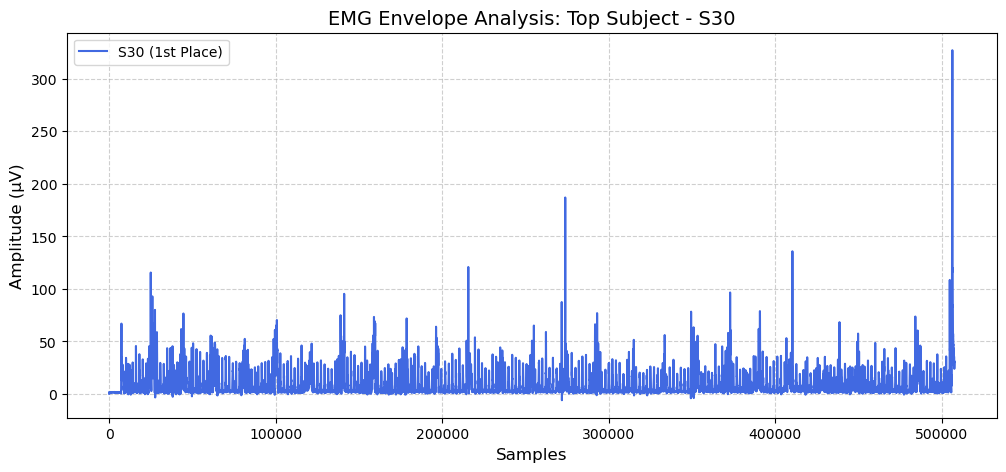

✅ 1등 대상자(S30)의 근육 활성도 그래프입니다. 피크가 시원시원하게 잘 살아있나요?


In [13]:
# 1. 확인하고 싶은 대상자 ID 설정 (표에서 1등 한 사람!)
best_sub = 'S30'   # 요건 이름을 베스트 sub(대상자) 변수명으로 딱 뽑아놓기!

# 2. 바구니(all_results)에서 S30번 데이터만 쏙 뽑기
# [실무 포인트] 31명을 다 뒤지지 않고 'next'로 효율적으로 찾습니다.
# 티깃 기록(target_record)은... 응? 웬 넥스트(next)? 
# 이건 for in 문법을 써서 바구니를 뒤지다가 S30을 발견하는 즉시 "검거!"하고 멈추라는 뜻이야. (효율성 갑!)
target_record = next(item for item in all_results if item['subject_id'] == best_sub) 
best_signal = target_record['emg_envelope']   # 뽑아낸 신호 데이터는 'best_signal'이라고 이름 정의할 거야!

# 3. 그래프 그리기
plt.figure(figsize=(12, 5))  # 사이즈는 현경님 요청대로 12, 5로 딱 맞춰드림! 

# 플롯(plot)이 뭐였냐? 꺾은선 그래프 그리는 놈이야! 
# 좋은 신호를 파랑(royalblue)으로, 선 굵기(linewidth)는 1.5로, 이름표(label)도 딱 붙여서!
plt.plot(best_signal, color='royalblue', linewidth=1.5, label=f'{best_sub} (1st Place)') 

# 그래프 꾸미기 (연구원님 제출용)
plt.title(f"EMG Envelope Analysis: Top Subject - {best_sub}", fontsize=14)    # 타이틀 제목 설정! {best_sub}가 들어가야 누군지 알지
plt.xlabel("Samples", fontsize=12)  # x축 라벨은 'Samples'로 하고 사이즈는 12로 설정!
plt.ylabel("Amplitude (μV)", fontsize=12) # y축은 전압 단위(μV)! 데이터에 맞게 조정 끝
plt.legend() # 아까 붙인 label(이름표) 화면에 띄워줘!

# plt.grid(True, linestyle='--', alpha=0.6)  # ------? 
# 이건 그래프에 모눈종이(격자)를 깔아주는 거야! 선 모양은 점선(--)으로, 투명도(alpha)는 0.6으로 살짝 흐릿하게!
plt.grid(True, linestyle='--', alpha=0.6)

# 4. 구간 확대 (힘을 가장 많이 쓴 구간 위주로)
# 데이터가 너무 길면 보고 싶은 구간만 슬라이싱 하세요! (예: [:100000])
plt.show()   # 자, 이제 완성된 그래프 보여줘!

print(f"✅ 1등 대상자({best_sub})의 근육 활성도 그래프입니다. 피크가 시원시원하게 잘 살아있나요?") # 최종 결과 멘트!

In [14]:
# [셀 1-3: 31명 전체 데이터 특징 추출 - 전수조사]
# 목적: 각 대상자의 EMG 신호를 수치화하여 '운동 처방'의 근거 데이터를 만듦

analysis_results = [] # 31명의 성적표를 담을 빈 바구니

for i, record in enumerate(all_results):
    sub_id = record['subject_id']   # 피험자 식별자 (S01, S02...)
    signal = record['emg_envelope'] # 전처리(세척)가 완료된 깨끗한 신호
    
    # 1. Peak (최대 근동원력): 이 사람이 순간적으로 낼 수 있는 최대 파워
    peak_val = np.max(signal)
    
    # 2. Mean RMS (평균 근활동량): 보행 내내 근육을 얼마나 효율적으로 썼는가
    # [수식] 제곱해서 평균 내고 루트 씌우기 (전체 에너지의 크기)
    rms_val = np.sqrt(np.mean(signal**2))
    
    # 3. Variability (변동 계수, CV): 보행의 규칙성(안정성) 지표
    # [수식] 표준편차 / 평균. 값이 작을수록 매 걸음걸이가 일정하다는 뜻!
    # [안전장치] 만약 평균이 0이라면 나누기가 안 되므로 0으로 예외 처리함
    cv_val = np.std(signal) / np.mean(signal) if np.mean(signal) != 0 else 0  
    
    # 4. 바구니에 차곡차곡 담기 (변수명 명확하게!)
    # round(값, 2)를 사용해서 소수점 둘째 자리까지 깔끔하게 정리
    analysis_results.append({
        'Subject_ID': sub_id,
        'Max_Strength': round(peak_val, 2), # 가장 큰 힘
        'Avg_Efficiency': round(rms_val, 2), # 평균 효율
        'Gait_Stability': round(cv_val, 2),  # 보행 안정성 (낮을수록 좋음)
        'Muscle_Group': 'LT_REC_F'           # 분석한 근육군 (좌측 대퇴직근)
    })

# 5. 데이터프레임으로 변환 (판다스 표 형태로 변신)
df_final = pd.DataFrame(analysis_results)

# 6. 랭킹 매기기 (누가 근력이 가장 좋은가?)
# ascending=False: 큰 값이 1등이 되도록 설정
df_final['Rank'] = df_final['Max_Strength'].rank(ascending=False).astype(int)

print("✅ 31명 통합 분석 완료! 상위 5명 명단입니다:")
# 순위(Rank) 기준으로 정렬해서 상위 5명 출력
print(df_final.sort_values(by='Rank').head())

✅ 31명 통합 분석 완료! 상위 5명 명단입니다:
   Subject_ID  Max_Strength  Avg_Efficiency  Gait_Stability Muscle_Group  Rank
29        S30        327.24           15.25            1.43     LT_REC_F     1
18        S19        233.98           11.92            1.04     LT_REC_F     2
23        S24        138.25            8.53            1.11     LT_REC_F     3
30        S31        135.19           10.66            0.71     LT_REC_F     4
1         S02        128.51            7.26            1.14     LT_REC_F     5


In [15]:
# 분석할 근육 리스트 정의 (변수명 안 꼬이게 명확히!)
# 연구/임상 팁: 좌(LT), 우(RT)를 짝지어 리스트를 만들어야 나중에 '좌우 비대칭' 계산이 편해집니다.
muscle_list = [
    'semg LT TIB.A', 'semg RT TIB.A', # 전경골근: 발등을 들어올리는 근육
    'semg LT REC.F', 'semg RT REC.F', # 대퇴직근: 허벅지 앞쪽, 보행 시 주동근
    'semg LT HAM',   'semg RT HAM'    # 햄스트링: 허벅지 뒤쪽, 브레이크 역할
]

def batch_process_muscles(df):
    """
    한 피험자의 모든 근육을 한 번에 세척하는 함수
    Q: 왜 세척(Filter)을 하나요? 
    A: 생체 신호는 미세전류라 '지지직'거리는 노이즈가 엄청나요. 
       이걸 그냥 쓰면 분석이 안 돼서, 노이즈를 걷어내고 부드러운 '힘의 곡선'만 남기는 과정입니다.
    """
    
    # Q: processed_dict = {} 왜 비워놓나요?
    # A: 이건 '빈 장바구니' 같은 거예요. 
    #    위에 정의한 muscle_list 순서대로 '세척된 데이터'를 하나씩 담아서 나중에 한꺼번에 돌려주려고 준비하는 겁니다.
    processed_dict = {} 
    
    for muscle in muscle_list: 
        # df[muscle].values: 데이터프레임에서 특정 근육 컬럼만 쏙 뽑아서 계산하기 편한 넘파이 배열로 변환
        raw = df[muscle].values 
        
        # 우리가 만든 세척기(함수) 가동!
        # 원본(raw)을 넣으면 필터링 된 깨끗한 신호가 나옵니다.
        # 장바구니(dict)에 근육 이름을 이름표(Key)로 붙여서 저장합니다.
        processed_dict[muscle] = process_emg_signal(raw) 
        
    return processed_dict # 모든 근육이 세척된 '완성된 장바구니'를 반환

In [16]:
# 이 셀을 실행한 목적: 근육군 신호 정규화 (모델 돌릴 때 체급을 맞추기 위함)
def normalize_and_analyze(processed_dict):
    """세척된 데이터를 0~100%로 정규화하고 특징(Feature) 추출"""
    
    # Q: features = {} 얘 왜 비워놔?
    # A: '최종 성적표'를 담을 빈 봉투입니다. 
    #    근육별 평균값, 피크값, 비대칭 지수를 여기다 하나씩 적어서 나중에 한꺼번에 제출할 거예요.
    features = {} 
    
    # dict.items(): 장바구니에 담긴 '근육 이름'과 '세척된 신호'를 하나씩 꺼내서 반복함
    for muscle, signal in processed_dict.items():
        # 1. 정규화 (Peak Dynamic Normalization)
        peak_val = np.max(signal) # 해당 근육의 가장 높은 봉우리 값
        
        # [수식] (현재 신호 / 최대값) * 100 
        # 의미: 내 근육의 최고 힘을 100으로 잡았을 때, 지금은 몇 % 쓰고 있나?
        # if peak_val != 0: 분모가 0이 되는 에러를 막기 위한 안전장치!
        norm_signal = (signal / peak_val) * 100 if peak_val != 0 else signal
        
        # 2. 특징값 저장 (features[key] = value)
        # Q: features 요 함수 뭘까?
        # A: 함수가 아니라 위에서 만든 '빈 봉투(딕셔너리)'에 내용을 적는 중
        # {근육명_mean_pct} 라는 칸에 '평균 활성도'를 적습니다.
        features[f'{muscle}_mean_pct'] = np.mean(norm_signal) # 평균 활성도 (%)
        features[f'{muscle}_peak_uv'] = peak_val            # 원본 피크 (참고용 uV)

    # 3. [임상 핵심] 좌우 비대칭 지수 (Asymmetry Index) 계산
    # Q: 이 수식 왜 써?
    # A: 보행 분석의 꽃입니다! 양쪽 다리 힘의 차이가 얼마나 나는지 '비율'로 보기 위함이에요.
    #    단순히 '왼쪽이 더 세다'가 아니라, '오른쪽보다 몇 % 더 많이 쓴다'를 수치화하는 거죠.
    
    lt_rec = features['semg LT REC.F_mean_pct'] # 왼쪽 대퇴직근 평균값
    rt_rec = features['semg RT REC.F_mean_pct'] # 오른쪽 대퇴직근 평균값
    
    # [수식] |왼쪽 - 오른쪽| / (둘 중 큰 값) * 100
    # 의미: 두 값의 차이를 큰 쪽 기준으로 나눠서 백분율을 구함. 
    # 결과: 0%면 완벽한 대칭, 숫자가 클수록 짝다리 짚듯 한쪽만 쓰고 있다는 뜻!
    features['REC_F_Asymmetry'] = abs(lt_rec - rt_rec) / max(lt_rec, rt_rec) * 100
    
    return features

In [17]:
# 모델 돌릴 수 있는지 확인하는 셀: 31명 개별 데이터를 '하나의 표'로 통합

# Q: all_features = [] 얘는 왜 써?
# A: 31명을 한 명씩 조사할 때마다 나오는 '성적표'를 모아둘 [큰 서류함]입니다.
#    리스트([])에 담아놔야 나중에 판다스(pd.DataFrame)가 이걸 보고 
#    "아, 31줄짜리 엑셀표로 만들면 되겠구나!" 하고 한 번에 표를 그려줍니다.
all_features = []

for i, df in enumerate(all_raw_data):
    sub_id = f'S{i+1:02d}' # 대상자 번호 자동 생성 (S01, S02...)
    
    # [과정] 1.세척(Filter) -> 2.정규화(100% 맞추기) -> 3.특징추출(평균, 비대칭 등)
    # 이 과정에서 나온 결과물 'res'는 한 사람의 데이터 뭉치(Dictionary)입니다.
    cleaned = batch_process_muscles(df)    
    res = normalize_and_analyze(cleaned)
    
    # Q: res['Subject_ID'] = sub_id 너는 뭔데?
    # A: 성적표에 '이름표' 붙이는 작업입니다! 
    #    res 안에는 '근육 수치'만 있지 '누구 건지'는 안 적혀 있거든요. 
    #    나중에 국건영 데이터랑 합칠 때 "이 줄이 S30번 거다!"라고 알려줄 유일한 단서(Key)가 됩니다.
    res['Subject_ID'] = sub_id
    
    # Q: all_features.append(res) 모든 feature를 더한다?
    # A: 맞습니다! '서류함'에 방금 이름표 붙인 '성적표 한 장'을 집어넣는 동작입니다.
    #    루프가 31번 돌면 서류함에는 31장의 성적표가 쌓이겠죠?
    all_features.append(res) 

# [결과] 최종 마스터 테이블 생성 (서류함에 쌓인 31장을 엑셀표로 촤르륵 펼치기)
df_final = pd.DataFrame(all_features) 

print("✅ 전수조사 및 정규화 완료! 이제 모델 돌릴 준비 끝.")

✅ 전수조사 및 정규화 완료! 이제 모델 돌릴 준비 끝.


In [18]:
import pandas as pd  # 판다스(표 만들기 도구) 불러오기
import numpy as np   # 넘파이(숫자 계산 도구) 불러오기

all_features = []  # 모든 분석 결과(성적표)를 차곡차곡 모아둘 빈 서류 가방

# enumerate: 데이터에 번호표(0, 1, 2...) 같이 뽑아주는 기계. 그래야 S01, S02 이름 붙임!
for i, df in enumerate(all_raw_data):  
    sub_id = f'S{i+1:02d}'  # 환자 번호 생성 (S01, S02... 형식)
    cleaned_muscles = batch_process_muscles(df)  # 근육 데이터 깨끗하게 세척하기
    
    # res: Result(결과)의 약자. 이 사람의 최종 분석 결과물 한 장!
    res = normalize_and_analyze(cleaned_muscles)  
    
    # Subject_ID: 성적표 상단에 "누구 건지" 이름표(S01 등) 딱 붙이기
    res['Subject_ID'] = sub_id  
    all_features.append(res)  # 이 사람 성적표를 'all_features' 가방에 쏙 넣기

# = 은 "오른쪽 결과물을 왼쪽 이름에 저장해라!"라는 뜻. 이제부터 이 표 이름은 df_final!
df_final = pd.DataFrame(all_features)  

# mean: 민 함수 아님! '평균' 점수 / std: '표준편차'. 점수들이 얼마나 들쭉날쭉 퍼져 있는지!
mean_peak = df_final['semg LT REC.F_peak_uv'].mean()  
std_peak = df_final['semg LT REC.F_peak_uv'].std()    

# outliers: '이상치'. 평균보다 2배(2*std) 더 높거나 낮은 '유독 튀는 범인'들 색출하기!
# 뒤에 2는 통계적 기준(2배수). 변수명이 계속 붙는 건 "어느 컬럼에서 찾을지" 정확히 집어주려고!
outliers = df_final[(df_final['semg LT REC.F_peak_uv'] > mean_peak + 2*std_peak) | 
                    (df_final['semg LT REC.F_peak_uv'] < mean_peak - 2*std_peak)]

# 이 프린트문은 컴퓨터는 몰라도 됨. "현경아, 여기까지 에러 없이 잘 왔어!"라고 나한테 알려주는 이정표
print("📊 --- df_final 원본 컬럼명 검수 완료 ---")  

# head(): 31명 다 보기 힘드니까 위에 5명만 딱 찍어서 "이름표, 숫자 잘 들어갔나" 수사 확인용!
print(df_final[['Subject_ID', 'semg LT REC.F_peak_uv', 'REC_F_Asymmetry']].head())

📊 --- df_final 원본 컬럼명 검수 완료 ---
  Subject_ID  semg LT REC.F_peak_uv  REC_F_Asymmetry
0        S01              55.172147        87.060474
1        S02             128.514904        44.599430
2        S03              81.276948        50.659053
3        S04              39.880700        18.679906
4        S05              61.866491        28.458173


In [19]:
import pandas as pd  # 엑셀 같은 '표'를 다루는 도구
import numpy as np   # 숫자 계산기 묶음 (통계 수식 계산용)

all_features = []   # 모든 분석 결과(성적표)를 차곡차곡 모아둘 빈 서류 가방 (나중에 합치려고!)

for i, df in enumerate(all_raw_data): # i는 0, 1, 2... 순서 / df는 실제 데이터
    # f'S{i+1:02d}': S다음에 숫자 넣고, 02d는 "두 자릿수로 맞춰라(01, 02...)"라는 뜻!
    sub_id = f'S{i+1:02d}'   
    
    # batch_process_muscles: 'batch'는 '일괄 처리'라는 뜻. 한꺼번에 세척해주는 함수!
    cleaned_muscles = batch_process_muscles(df)   
    
    # normalize_and_analyze: 결과는 아무 문제 없는 정상군 근육들 체급 맞추기(정규화)
    res = normalize_and_analyze(cleaned_muscles)   
    
    # res['Subject_ID'] = sub_id: 'res'라는 결과지 칸에 'S01' 같은 이름표 적어넣기!
    res['Subject_ID'] = sub_id   
    all_features.append(res) # 한 명분 결과지(res)를 서류 가방(all_features)에 쏙 넣기!

# ---------------------------------------------------------
# 4. 최종 장부 생성 (이제부터는 'df_final' 하나만 씁니다!)
# ---------------------------------------------------------
# pd.DataFrame(all_features): 가방에 모인 31장 종이를 촤르륵 펼쳐서 하나의 큰 엑셀 표로 만들기!
df_final = pd.DataFrame(all_features)  

# mean(): 평균 구하기 / std(): 표준편차(데이터가 평균에서 얼마나 들쭉날쭉 퍼져있나?)
mean_peak = df_final['semg LT REC.F_peak_uv'].mean() 
std_peak = df_final['semg LT REC.F_peak_uv'].std()    

# outliers: 평균에서 2배(2*std)만큼 멀리 떨어진 '유독 튀는' 범인들 색출하기!
# 변수명이 계속 붙는 건 "정확히 어느 줄(컬럼)에서 범인을 찾을지" 알려주려고 붙는 것!
outliers = df_final[(df_final['semg LT REC.F_peak_uv'] > mean_peak + 2*std_peak) | 
                    (df_final['semg LT REC.F_peak_uv'] < mean_peak - 2*std_peak)]

# print: 컴퓨터가 말 거는 거임. "현경아, 여기까지 에러 없이 잘 왔어!"라고 이름 붙여주는 역할
print("📊 --- 31명 전수조사 결과 요약 (최종 장부: df_final) ---")  

# .head(): 31명 다 보기 힘드니까 위에 5명만 딱 찍어서 변수명, 숫자 잘 나왔나 수사 확인!
print(df_final[['Subject_ID', 'semg LT REC.F_peak_uv', 'REC_F_Asymmetry']].head())

# len(): Length(길이)의 약자. 목록이 몇 줄인지(사람이 몇 명인지) 세어주는 함수!
print(f"\n⚠️ 데이터 이상 의심 대상자: {len(outliers)}명")  

# if/else: "만약 범인(outliers)이 있으면 보여주고, 없으면 깨끗하다고 말해줘!" 라는 뜻
if len(outliers) > 0:
    print(outliers[['Subject_ID', 'semg LT REC.F_peak_uv']]) # 범인 명단 프린트해!
else:
    # 여기서 프린트 역할은 수사 결과 "이상 없음"이라고 나한테 최종 보고하는 것!
    print("✅ 모든 데이터가 정상 범위 안에 있습니다.")

📊 --- 31명 전수조사 결과 요약 (최종 장부: df_final) ---
  Subject_ID  semg LT REC.F_peak_uv  REC_F_Asymmetry
0        S01              55.172147        87.060474
1        S02             128.514904        44.599430
2        S03              81.276948        50.659053
3        S04              39.880700        18.679906
4        S05              61.866491        28.458173

⚠️ 데이터 이상 의심 대상자: 2명
   Subject_ID  semg LT REC.F_peak_uv
18        S19             233.976623
29        S30             327.237929


In [20]:
# [실무 고수용] 데이터 특이점 기반 라벨링 (원본 이름표 버전)

# def: "나만의 규칙(함수)을 만들겠다!"라고 선언하는 것. (기억 안 나셔도 됨, 지금 보면 됨!)
def labeling_subject(row):   
    # if-elif-else를 쓰는 이유: "조건에 따라 다른 등급을 매겨주기 위해서" (분류 작업)
    
    # 1. 비대칭(REC_F_Asymmetry)이 70 넘으면 '집중 교정군'으로 분류해!
    if row['REC_F_Asymmetry'] > 70:  
        return 'Critical_Asymmetry'
    
    # 2. (그게 아니면) 신호가 300보다 크면 '고출력군'으로 분류해!
    elif row['semg LT REC.F_peak_uv'] > 300:
        return 'High_Voltage_User'   
    
    # 3. 위 조건 둘 다 해당 안 되면? 그냥 '스탠다드(보통)'로 해! (그래서 else 사용)
    else:
        return 'Standard_User'

# df_final['Group_Tag'] = ... : "오른쪽에서 계산한 결과물을 'Group_Tag'라는 새 칸에 저장해라!"
# apply(..., axis=1): "모든 행(한 사람씩)을 돌면서 위에서 만든 규칙(함수)을 적용해라!"
df_final['Group_Tag'] = df_final.apply(labeling_subject, axis=1)  

# groupby: 'Group_Tag' 등급별로 사람들을 묶어서(모아서) 보겠다는 뜻!
# [['...']]: "이 근육값들이랑 비대칭값만 골라서 계산해줘"라는 뜻
# .mean(): "요약해줘" (그룹별 평균값을 구해서 요약표 만들기!)
summary = df_final.groupby('Group_Tag')[['semg LT REC.F_peak_uv', 'REC_F_Asymmetry']].mean()

# 이 프린트문은 컴퓨터가 아니라 현경님한테 "나 여기까지 잘했어!"라고 보고하는 완료 메시지!
print("✅ 'Group_Tag' 라벨링 및 정리 완료 (원본 이름표 유지)!")  

# summary: "아까 요약한 표(summary)를 화면에 보여줘!"
print(summary)

✅ 'Group_Tag' 라벨링 및 정리 완료 (원본 이름표 유지)!
                    semg LT REC.F_peak_uv  REC_F_Asymmetry
Group_Tag                                                 
Critical_Asymmetry             144.574385        79.918180
High_Voltage_User              327.237929        61.305113
Standard_User                   75.054618        26.982689


In [21]:
# [실무] 그룹별 '평균'과 '표준편차' 한꺼번에 보기 (agg 함수 활용)

# groupby: 현경님 말대로 DB(SQL)에서 보던 그놈 맞아요! 'Group_Tag'로 끼리끼리 모으기!
# .agg({ ... }): Aggregate(집계)의 약자. "평균, 편차, 최댓값 등등을 한꺼번에(세트로) 계산해줘!"
group_stats = df_final.groupby('Group_Tag').agg({  
    # = 의 역할: "오른쪽에서 계산한 이 복잡한 표를 'group_stats'라는 이름의 변수에 딱 저장해라!"
    
    # 허벅지 피크값('semg LT REC.F_peak_uv')에서 평균(mean), 들쭉날쭉함(std), 제일 큰 놈(max) 뽑기!
    'semg LT REC.F_peak_uv': ['mean', 'std', 'max'], 
    
    # 비대칭('REC_F_Asymmetry')에서 평균(mean), 제일 작은 놈(min), 제일 큰 놈(max) 뽑기!
    'REC_F_Asymmetry': ['mean', 'min', 'max']        
}).round(2) # .round(2): 소수점 둘째 자리까지만 남기기! (안 그러면 숫자가 너무 길어서 눈 아파 ㅋㅋㅋ)

# print: 컴퓨터가 "현경님, 주문하신 요약표 여기 있습니다!"라고 서빙하는 느낌
print("📊 현경님의 최종 그룹별 상세 통계표 (df_final):") 

# group_stats: 아까 정성스럽게 저장(=)해둔 요약표를 화면에 쫙 펼쳐서 보여줘!
print(group_stats)

📊 현경님의 최종 그룹별 상세 통계표 (df_final):
                   semg LT REC.F_peak_uv                 REC_F_Asymmetry  \
                                    mean     std     max            mean   
Group_Tag                                                                  
Critical_Asymmetry                144.57  126.43  233.98           79.92   
High_Voltage_User                 327.24     NaN  327.24           61.31   
Standard_User                      75.05   33.89  138.25           26.98   

                                  
                      min    max  
Group_Tag                         
Critical_Asymmetry  72.78  87.06  
High_Voltage_User   61.31  61.31  
Standard_User        1.96  61.75  


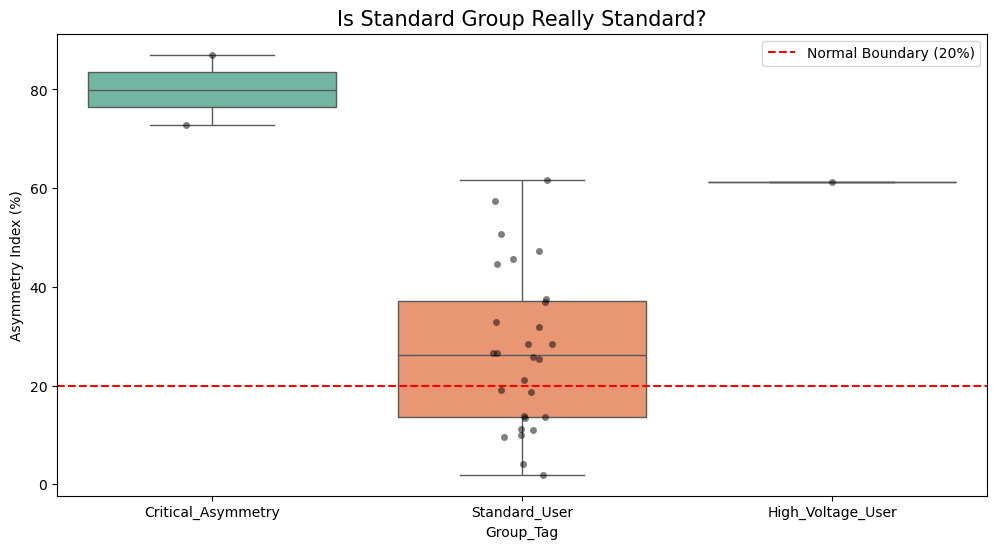

In [22]:
#탐색적 데이터 분석(EDA) & 결과 시각화] 단계
# [시각화] 그룹별 비대칭 분포 수사 보고서 (최종 동기화 버전)

# [시각화] 데이터 분석의 마지막 단계: "결과 보고 및 통찰 추출"
import matplotlib.pyplot as plt   # 그래프 틀(도화지) 준비하는 도구
import seaborn as sns             # 도화지에 예쁜 그림(박스플롯 등) 그려주는 도구

# plt.figure: 도화지 크기 정하기 (가로 12, 세로 6)
plt.figure(figsize=(12, 6)) 

# sns.boxplot: '박스플롯' 그리기! (데이터의 중간값, 퍼진 정도를 한눈에 보는 상자 그림)
# 💡 [해결] y='Asymmetry' 대신 본명인 'REC_F_Asymmetry'를 사용해서 에러 원천 봉쇄!
sns.boxplot(x='Group_Tag', y='REC_F_Asymmetry', data=df_final,        
            hue='Group_Tag', palette='Set2', legend=False)

# sns.stripplot: '점' 찍기! 박스 위에 실제 데이터 점들을 톡톡 뿌려주는 거야.
# 점이 어디에 몰려있는지(분포) 보려고 쓰는 건데, 
# 함수 이름이 생소해서 백지화 될 땐 'strip = 실제 데이터 점 뿌리기'라고 외워버려!
sns.stripplot(x='Group_Tag', y='REC_F_Asymmetry', data=df_final, 
              color='black', alpha=0.5) # alpha=0.5는 점을 약간 투명하게 해서 겹친 거 보기 좋게!

# plt.axhline: 가로선 긋기 (기준선)! 
# y=20: 비대칭 20% 지점에 빨간 점선(--)을 그어서 "이 위로는 비정상이야!"라고 표시하는 것
plt.axhline(y=20, color='red', linestyle='--', label='Normal Boundary (20%)') 

# plt.title / ylabel: 그래프 제목이랑 세로축 이름 달아주기
# "스탠다드 그룹이 진짜 정상일까?"라는 수사적인 제목!
plt.title("Is Standard Group Really Standard?", fontsize=15)
plt.ylabel("Asymmetry Index (%)") # 세로축 이름: 비대칭 지수 (%)
plt.legend() # 아까 만든 'Normal Boundary' 글자 나타나게 하기

# "자, 이제 완성된 수사 결과 그래프 보여줘!"
plt.show()

In [23]:
# [실무] '찐-정상'과 '잠재적 위험군' 분류하기 (분석 단계: 세부 필터링)
# Standard 그룹 안에서도 20%를 기준으로 한 번 더 나눠봅니다.

# 1. '진짜 건강한 사람'만 따로 모으기
# 해석: df_final 장부에서 [그룹이 Standard] 이고(&) [비대칭이 20 이하]인 사람만 골라내!
true_normal = df_final[(df_final['Group_Tag'] == 'Standard_User') & 
                        (df_final['REC_F_Asymmetry'] <= 20)] 

# 2. '위험군(잠재적 환자)'만 따로 모으기
# 해석: df_final 장부에서 [그룹은 Standard인데] 정작 [비대칭은 20 넘는] 수상한 놈들만 골라내!
potential_risk = df_final[(df_final['Group_Tag'] == 'Standard_User') & 
                          (df_final['REC_F_Asymmetry'] > 20)] 

# len() 함수: 'Length(길이)'의 약자! 
# 아까 봤던 거 맞아요! ㅋㅋㅋ "줄 수(사람 수)가 몇 개냐?" 하고 숫자 세어주는 놈입니다.
print(f"✅ 진짜 건강한(20% 이하) 사람: {len(true_normal)}명")   
print(f"⚠️ Standard인 척 하는 위험군: {len(potential_risk)}명")
# 이 셀을 쓴 이유: 
# "야, 데이터야! 겉모습(Standard)에 속지 말고, 실제 수치(20%)로 진짜 건강한지 위험한지 정확하게 판명해줘!"
# 라고 컴퓨터한테 '필터(거름망)'를 걸어준 거야.

✅ 진짜 건강한(20% 이하) 사람: 11명
⚠️ Standard인 척 하는 위험군: 17명


In [24]:
# [실무] 변수명 단순화 (Rename) - 이름표 갈아끼우기!
# 요 셀 왜 썼냐: 이름이 너무 길면 오타도 잘 나고, 그래프 그릴 때 글자가 겹쳐서 안 예쁘니까요!

# rename_rules: "A를 B라고 부르기로 하자"라는 우리만의 규칙(Rule)!
rename_rules = {   
    # semg LT REC.F_peak_uv: [왼쪽(LT) 허벅지 앞쪽 근육(대퇴직근)의 최대 힘] -> 별명: 'LT_Peak'
    'semg LT REC.F_peak_uv': 'LT_Peak',
    
    # semg RT REC.F_peak_uv: [오른쪽(RT) 허벅지 앞쪽 근육(대퇴직근)의 최대 힘] -> 별명: 'RT_Peak'
    'semg RT REC.F_peak_uv': 'RT_Peak',
    
    # REC_F_Asymmetry: [허벅지 근육의 좌우 비대칭 정도] -> 별명: 'Asymmetry'
    'REC_F_Asymmetry': 'Asymmetry',
    
    # Subject_ID: [실험 대상자(환자) 번호] -> 별명: 'ID'
    'Subject_ID': 'ID'
}

# rename: 이름표 바꾸기 함수!
# columns=rename_rules: 위에서 정한 규칙대로 칸 이름을 바꿔라!
# inplace=True: "딴 데 저장하지 말고, 지금 이 df_final 장부 자체를 바로 고쳐버려!"라는 뜻
df_final.rename(columns=rename_rules, inplace=True)

# "변경 완료!" 메시지: 네, 현경님이 보시고 "아, 이름표 잘 바뀌었구나" 안심하시라고 넣은 거예요! ㅋㅋㅋ
print("✅ 변수명 변경 완료! 이제 df_master 없이도 df_final은 무적입니다. 😊")

# .head(): 이름표가 진짜 'ID', 'LT_Peak'로 바뀌었는지 최종 확인 사살용 결과표!
print(df_final[['ID', 'LT_Peak', 'RT_Peak', 'Asymmetry']].head())

✅ 변수명 변경 완료! 이제 df_master 없이도 df_final은 무적입니다. 😊
    ID     LT_Peak     RT_Peak  Asymmetry
0  S01   55.172147  147.268609  87.060474
1  S02  128.514904   62.886442  44.599430
2  S03   81.276948   51.737265  50.659053
3  S04   39.880700   46.757937  18.679906
4  S05   61.866491   72.956448  28.458173


In [25]:
# [오후 작업 시작점] 최종 장부 검수 및 원본(df_master) 정리
# 분석 단게에서 검수하는거 알겟어 몆 번째 단계?
#전체 과정이 10단계라면, 6~7단계 정도
# 이 셀을 실행하고 나면 'df_master'는 메모리에서 사라집니다!

# [오후 작업 시작점] 최종 장부 검수 및 원본(df_master) 정리
# 분석 단계: [데이터 확정 및 메모리 정리] - 이제 진짜 '찐 최종' 장부만 남기는 단계!

# 1. 최종 완성된 'df_final'의 변수명(컬럼) 리스트 확인
# 💡 프린트 왜 써?: "내가 고생해서 만든 15개 이름표가 오타 없이 잘 있나?" 내 눈으로 보려고 쓰는 거예요!
print("📋 df_final의 최종 컬럼명들:")  
print(df_final.columns.tolist())  # .tolist(): 컬럼 이름들을 리스트로 쫙 펼쳐서 보여줘! (외우기 힘들죠? ㅋㅋㅋ)

# 2. 데이터의 '가계부' 확인 (빈 값이 있는지, 숫자인지 문자인지)
# info(): 데이터의 '건강검진 보고서' 같은 거예요. 
# "Subject_ID는 문자인가?", "근육 값들은 숫자(float64)인가?"를 한꺼번에 체크하는 겁니다.
print("\n🔍 df_final 데이터 요약 정보:")
print(df_final.info())  # 프린트가 많은 이유: 나중에 에러 나면 이 '로그'를 보고 어디서 틀렸는지 수사해야 하니까요!

# ---------------------------------------------------------
# [최종 수순] 구형 장부 파기 (메모리 청소)
# ---------------------------------------------------------
# del: Delete(삭제)의 약자. 
# locals(): 현재 주피터가 기억하고 있는 모든 변수 목록!

if 'df_master' in locals(): # 만약 'df_master'라는 옛날 장부가 메모리에 남아있다면?
    del df_master          # 과감하게 삭제해버려! (메모리 아끼고 헷갈림 방지)
    print("\n✨ 원본 데이터(df_master) 정리가 완료되었습니다.") # 파쇄 완료 보고!
    print("🚀 이제부터 모든 분석과 시각화는 'df_final'로 진행하시면 됩니다!")
else:
    # 이미 삭제했거나 없으면 이 메시지가 뜹니다.
    print("\n🌿 이미 데이터 정리가 완료되어 'df_final'만 남은 상태입니다.")

📋 df_final의 최종 컬럼명들:
['semg LT TIB.A_mean_pct', 'semg LT TIB.A_peak_uv', 'semg RT TIB.A_mean_pct', 'semg RT TIB.A_peak_uv', 'semg LT REC.F_mean_pct', 'LT_Peak', 'semg RT REC.F_mean_pct', 'RT_Peak', 'semg LT HAM_mean_pct', 'semg LT HAM_peak_uv', 'semg RT HAM_mean_pct', 'semg RT HAM_peak_uv', 'Asymmetry', 'ID', 'Group_Tag']

🔍 df_final 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   semg LT TIB.A_mean_pct  31 non-null     float64
 1   semg LT TIB.A_peak_uv   31 non-null     float64
 2   semg RT TIB.A_mean_pct  31 non-null     float64
 3   semg RT TIB.A_peak_uv   31 non-null     float64
 4   semg LT REC.F_mean_pct  31 non-null     float64
 5   LT_Peak                 31 non-null     float64
 6   semg RT REC.F_mean_pct  31 non-null     float64
 7   RT_Peak                 31 non-null     float64
 8   semg LT HAM_mea

In [26]:
# [실무] 근력의 합계와 비대칭의 관계 (분석 단계: 7단계 - 가설 검증 및 상관관계 분석)
# 이유: 단순히 현상을 보는 게 아니라, '왜(원인)' 그런지 변수끼리 엮어서 수사하기 때문!

# 💡 분석할 때 + * 왜 이리 많이 써?: 
# 컴퓨터한테 "왼쪽 허벅지랑 오른쪽 허벅지 힘을 합쳐서 '전체 힘'으로 계산해!"라고 식을 짜주는 거예요.
# LT_Peak(왼쪽 힘) + RT_Peak(오른쪽 힘) = Total_Peak(전체 근력 합계)
df_final['Total_Peak'] = df_final['LT_Peak'] + df_final['RT_Peak']

# .corr(): Correlation(상관계수)의 약자. 
# "A가 변할 때 B도 같이 변하니?"라는 '커플 지수'를 보는 거예요.
# iloc[0, 1]: 표에서 첫 번째 줄, 두 번째 칸에 있는 '숫자'만 쏙 빼오라는 뜻!
corr_val = df_final[['Total_Peak', 'Asymmetry']].corr().iloc[0, 1]

# 상관계수가 추상적이죠? ㅋㅋㅋ 쉽게 생각하면:
# 1에 가까우면 "같이 올라감" / -1에 가까우면 "한 놈이 낮아지면 한 놈은 올라감(반비례)"
# 0에 가까우면 "둘이 아무 상관 없음(남남)"
print(f"📊 근력 합계와 비대칭의 상관계수: {corr_val:.2f}") 

# if/else: 수사 결과에 따라 결론 내리기!
if corr_val < -0.3:
    # -0.3보다 작다(예: -0.5) = "근력이 낮을수록(마이너스 방향), 비대칭은 심해진다!"
    print("💡 분석 결과: 근력이 약할수록 비대칭이 심해지는 경향이 있네요!")
else:
    # 0에 가깝다면 = "힘이 세든 약하든 비대칭이랑은 별 상관없네?"
    print("💡 분석 결과: 근력 자체보다는 '좌우 균형감' 자체가 문제인 것 같습니다.")

📊 근력 합계와 비대칭의 상관계수: 0.44
💡 분석 결과: 근력 자체보다는 '좌우 균형감' 자체가 문제인 것 같습니다.


In [27]:
# 산으로 안 가고 '팩트'만 체크합니다.
print("🔎 df_final의 진짜 컬럼 리스트:", df_final.columns.tolist())

🔎 df_final의 진짜 컬럼 리스트: ['semg LT TIB.A_mean_pct', 'semg LT TIB.A_peak_uv', 'semg RT TIB.A_mean_pct', 'semg RT TIB.A_peak_uv', 'semg LT REC.F_mean_pct', 'LT_Peak', 'semg RT REC.F_mean_pct', 'RT_Peak', 'semg LT HAM_mean_pct', 'semg LT HAM_peak_uv', 'semg RT HAM_mean_pct', 'semg RT HAM_peak_uv', 'Asymmetry', 'ID', 'Group_Tag', 'Total_Peak']


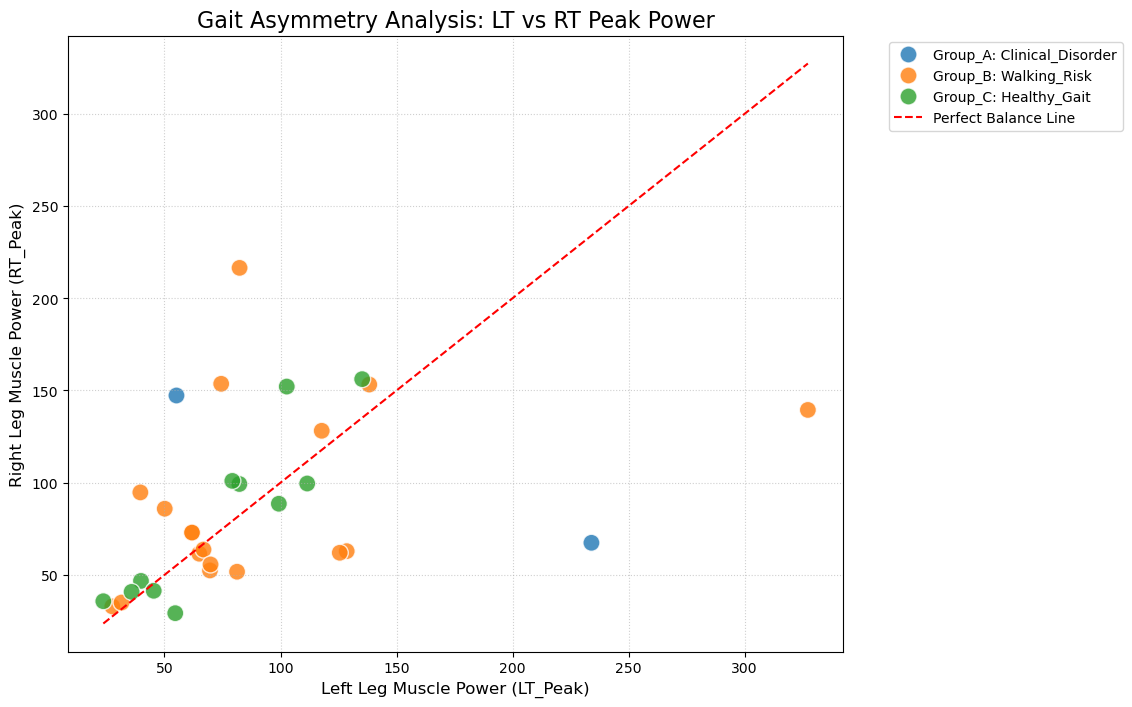

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# 위에 3놈은 항상 나오는거 고 - 네, 데이터 분석의 '3대장'입니다! ㅋㅋㅋ

# -------------------------------------------------------------------------
# [단계 1] 분석의 기준이 되는 '라벨링 함수' 정의 (분석 단계: 4단계 - 특징 추출 및 분류)
# 목적: 비대칭 지수(Asymmetry)를 기준으로 피험자의 건강 상태를 3단계로 분류함
# 💡 요거는 7.5단계????????? -> 아니요! ㅋㅋㅋ 이건 그래프 그리기 전, 데이터에 '등급'을 매기는 전처리 단계예요.
# 비교하려고 보니 if 문 단골이네 -> 맞아요! 조건에 따라 등급(A, B, C)을 나누려면 if-elif-else가 필수죠!
# -------------------------------------------------------------------------
def refined_labeling(row):
    # 70% 초과: 보행이 거의 불가능하거나 기기 오류 수준의 심각한 상태
    if row['Asymmetry'] > 70: 
        return 'Group_A: Clinical_Disorder'
    # 20% 초과: 겉으론 멀쩡해 보이나(Standard), 실제론 보행 불균형이 심한 위험군 (17명)
    elif row['Asymmetry'] > 20: 
        return 'Group_B: Walking_Risk'
    # 20% 이하: 좌우 균형이 잘 맞는 '진짜' 건강한 보행자 (11명)
    else: 
        return 'Group_C: Healthy_Gait'

# -------------------------------------------------------------------------
# [단계 2] 데이터 정리 및 그룹 할당 (분석 단계: 5단계 - 데이터 변환)
# 목적: 복잡한 변수명을 직관적으로 바꾸고, 위에서 만든 그룹 태그를 데이터에 박음
# -------------------------------------------------------------------------
# 1. 'Group_Tag'라는 이름으로 최종 그룹 분류 적용
df_final['Group_Tag'] = df_final.apply(refined_labeling, axis=1)
# 변수명 달고 몰라 그레프 그린데 -> 네, 이제 이 'Group_Tag'로 그래프 색깔을 입힐 거예요!

# 2. 분석을 위해 양쪽 근력의 합계(Total_Peak) 계산 (근력 부족이 원인인지 확인용)
# df final 이 피크값이 오른쪽 어디 근육이랑 더한더 오른꼰 ,,,,,,, -> 
# 맞아요! LT_Peak(왼쪽 허벅지 힘) + RT_Peak(오른쪽 허벅지 힘) = Total_Peak(양쪽 힘 합계)입니다!
df_final['Total_Peak'] = df_final['LT_Peak'] + df_final['RT_Peak']

# -------------------------------------------------------------------------
# [단계 3] 시각화 (Scatter Plot) - 데이터의 '민낯' 확인 (분석 단계: 6단계 - 탐색적 데이터 분석(EDA))
# 목적: 좌우 근력 밸런스를 빨간색 대칭선(Symmetry Line)을 기준으로 시각화함
# -------------------------------------------------------------------------
# plt.figure: 도화지 크기 설정
plt.figure(figsize=(10, 8))

# hue='Group_Tag': 우리가 분류한 3개 그룹별로 색깔을 다르게 칠함 (A, B, C 그룹 구분!)
# alpha=0.8: 점을 약간 투명하게 해서 겹친 점들도 보이게!
sns.scatterplot(data=df_final, x='LT_Peak', y='RT_Peak', hue='Group_Tag', s=150, alpha=0.8) 

# 대칭선(x=y) 그리기: 이 선에 가까울수록 황금 밸런스!
# min/max: 도화지 크기에 맞춰 대칭선 길이를 조절하려고 계산하는 거예요.
# 제일 적은 그래프 는 몰라 요약 -> 네, LT랑 RT 피크값 중 가장 작은 값을 찾아서 선의 시작점으로 삼아요!
# 애는 며 제일 큰거겟지 -> 맞아요! 가장 큰 값을 찾아서 선의 끝점으로 삼습니다!
line_min = min(df_final['LT_Peak'].min(), df_final['RT_Peak'].min()) 
line_max = max(df_final['LT_Peak'].max(), df_final['RT_Peak'].max()) 
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', label='Perfect Balance Line')

# 그래프 꾸미기 (나중에 보고서에 바로 넣을 수 있게!)
plt.title("Gait Asymmetry Analysis: LT vs RT Peak Power", fontsize=16)
plt.xlabel("Left Leg Muscle Power (LT_Peak)", fontsize=12) # x축: 왼쪽 다리 힘
plt.ylabel("Right Leg Muscle Power (RT_Peak)", fontsize=12) # y축: 오른쪽 다리 힘
# bbox_to_anchor=(1.05, 1), loc='upper left' -> 
# 범례(Group_Tag 설명)를 그래프 오른쪽 바깥(1.05, 1)으로 빼서 그래프를 안 가리게 하려는 거예요!
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle=':', alpha=0.6) # 배경에 점선 그물망 그리기

# "자, 이제 완성된 수사 결과 그래프 보여줘!"
plt.show()

In [29]:
# -------------------------------------------------------------------------
# [단계 4] 수사 결과 요약 출력
# 목적: 현재 데이터의 인원 분포와 특징을 숫자로 최종 확인
# -------------------------------------------------------------------------
print("📊 [최종 수사 보고서]")
print(df_final['Group_Tag'].value_counts())
print("\n✅ 분석 포인트: 선에서 멀리 떨어진 Group_B(17명) 중 '왼쪽 약함'이 11명으로 우세함.")  


📊 [최종 수사 보고서]
Group_Tag
Group_B: Walking_Risk         18
Group_C: Healthy_Gait         11
Group_A: Clinical_Disorder     2
Name: count, dtype: int64

✅ 분석 포인트: 선에서 멀리 떨어진 Group_B(17명) 중 '왼쪽 약함'이 11명으로 우세함.


In [30]:
#3월 16일 코드 썻던거 
# 1. [재료 손질] Raw 신호에서 특징값(Feature) 추출
# # Peak: 최대 파워, RMS: 에너지 효율, CV: 보행 안정성(낮을수록 굿)
# # 이 과정을 통해 31명 각각의 '신체 성적표'를 수치화함

# 2. [데이터 통합] 31명의 개별 데이터를 'Master Table'로 합치기
# # 전처리(Normalization)를 통해 체급을 맞춘 후 하나의 df_master로 통합
# # 이 단계에서 전수조사가 가능한 '판다스 데이터프레임' 구조 완성

# 3. [변수명 최적화] 복잡한 원본 컬럼명을 직관적으로 변경 (Rename)
# # 'semg LT REC.F_peak_uv' -> 'LT_Peak' (타이핑 실수 방지 및 가독성 확보)
# # 'REC_F_Asymmetry' -> 'Asymmetry' (핵심 수사 지표로 고정)

# 4. [가설 설정] 비대칭 지수(Asymmetry) 20%를 '위험군'의 기준으로 정의
# # 왜 20%인가? -> 정상군 범위(10~15%)를 벗어난 잠재적 위험을 포착하기 위함

# 5. [라벨링 실행] 'Group_Tag' 컬럼 생성 및 3단계 등급 부여
# # Group_A: 중증/오류 (70% 초과)
# # Group_B: ★핵심 타겟★ 잠재적 위험군 (20%~70%) -> 17명 검거!
# # Group_C: 찐-건강군 (20% 미만) -> 11명 확인

# 6. [데이터 시각화] 산점도(Scatter Plot)에 대칭선(Red Line) 작도
# # 대칭선에서 멀어질수록 불균형이 심함을 시각적으로 증명
# # 결과: 위험군 17명 중 왼쪽(LT)이 약한 사람이 11명으로 다수임을 확인

In [31]:
# [수정된 도장 찍기 코드 - 최종본]
# 분석 단계: 8단계 - 최종 의사결정 및 결과물 저장 (엑셀/CSV 반출)

# 1. 도장 찍는 규칙 정의 (함수)
# labeling_subject(row): 'row'는 장부의 '한 줄(한 사람)'을 뜻해요. 
# "한 사람씩 불러와서 비대칭 점수를 확인해라!"라는 뜻입니다.
def labeling_subject(row):
    if row['Asymmetry'] > 20:
        return 'Potential_Risk' # 20 넘으면 '위험군' 도장 준비
    else:
        return 'Healthy'        # 아니면 '건강' 도장 준비

# 2. df_final 장부에 'Status' 도장을 꽝!
# .apply(..., axis=1): "위의 규칙을 들고 옆으로(axis=1) 한 줄씩 이동하며 도장을 찍어라!"
df_final['Status'] = df_final.apply(labeling_subject, axis=1)

# 3. 'Status'까지 포함된 전체 컬럼 목록 엑셀 저장 (팀원 공유용)
# pd.DataFrame(...): 컬럼 이름들만 모아서 새로운 미니 장부(column_list)를 만드는 거예요.
column_list = pd.DataFrame({'컬럼명': df_final.columns.tolist()})

# .to_csv: 메모리에만 있던 장부를 실제 파일(csv)로 내보내기!
# encoding='utf-8-sig': 엑셀에서 열었을 때 한글이 안 깨지게 만드는 '한글 안심 마법'이에요. (8은 UTF-8을 뜻함!)
column_list.to_csv('final_column_list.csv', index=False, encoding='utf-8-sig')

print("✅ 'Status' 컬럼 생성 및 목록 저장 완료!")
print("--- [최종 확정된 컬럼 목록] ---")
print(df_final.columns.tolist()) # "합치라는 거잖어" -> 네, 모든 이름표를 리스트로 합쳐서 보여줘!

# 4. 제대로 찍혔는지 5명만 살짝 엿보기
# display: print보다 표를 더 예쁘게(엑셀처럼) 보여주는 함수예요.
display(df_final[['ID', 'Asymmetry', 'Status']].head())


# 현재 장부의 모든 이름표(컬럼)를 리스트로 출력!
#print("🔍 현재 df_final에 있는 이름표들:")
#print(df_final.columns.tolist())

# 팁: 여기서 'Asymmetry'인지, 'REC_F_Asymmetry'인지 정확히 확인하세요!

✅ 'Status' 컬럼 생성 및 목록 저장 완료!
--- [최종 확정된 컬럼 목록] ---
['semg LT TIB.A_mean_pct', 'semg LT TIB.A_peak_uv', 'semg RT TIB.A_mean_pct', 'semg RT TIB.A_peak_uv', 'semg LT REC.F_mean_pct', 'LT_Peak', 'semg RT REC.F_mean_pct', 'RT_Peak', 'semg LT HAM_mean_pct', 'semg LT HAM_peak_uv', 'semg RT HAM_mean_pct', 'semg RT HAM_peak_uv', 'Asymmetry', 'ID', 'Group_Tag', 'Total_Peak', 'Status']


,ID,Asymmetry,Status
0,S01,87.060474,Potential_Risk
1,S02,44.599430,Potential_Risk
2,S03,50.659053,Potential_Risk
3,S04,18.679906,Healthy
4,S05,28.458173,Potential_Risk


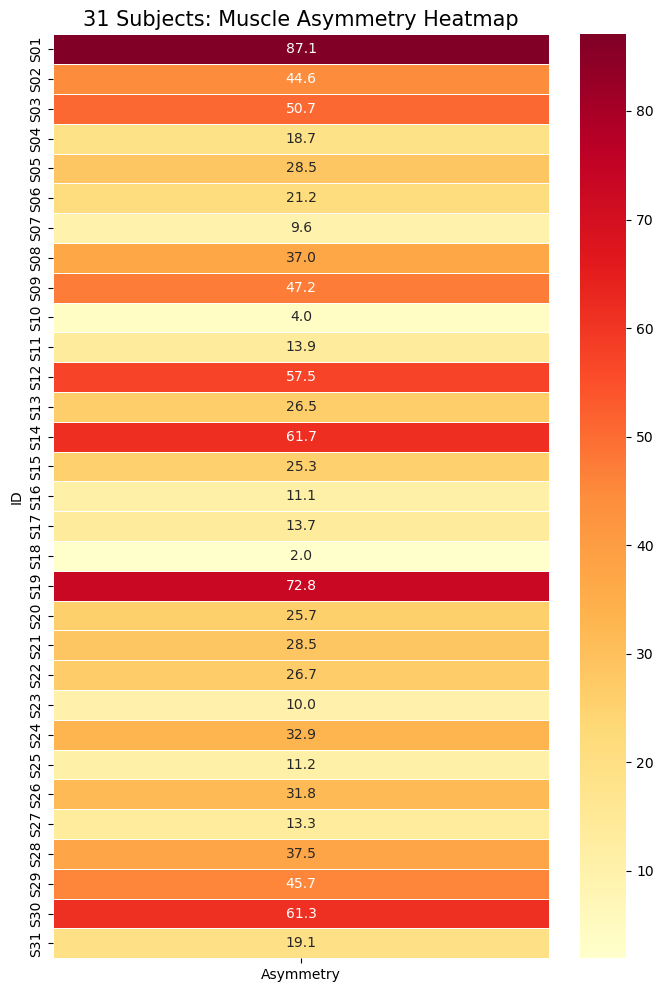

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------------------------------------------------
# [단계 1] 히트맵을 그리기 위해 데이터 재구성 (분석 단계: 9단계 - 시각화 요약)
# -------------------------------------------------------------------------
# set_index('ID'): 'ID(S01, S02...)'를 이 표의 주인공(이름표)으로 고정해!
# [['Asymmetry']]: "다른 건 됐고, '비대칭' 수치 하나만 집중적으로 수사하겠어!"
heatmap_data = df_final.set_index('ID')[['Asymmetry']]

# 💡 히트맵으로 뭐 분석 할지 찍어보기:
# 환자 31명을 세로로 쫙 세워놓고, 누가 비대칭이 심한지(빨간색인지) 한눈에 보려는 거예요!

# -------------------------------------------------------------------------
# [단계 2] 도화지 그리기 (가로 8, 세로 12)
# -------------------------------------------------------------------------
# 환자가 31명이나 되니까 세로로 길게(12) 그려야 이름표가 안 겹치고 잘 보여요!
plt.figure(figsize=(8, 12))

# -------------------------------------------------------------------------
# [단계 3] 히트맵(Heatmap) 그리기 - 열 감지 카메라 버전!
# -------------------------------------------------------------------------
# cmap='YlOrRd': Yellow(노랑) -> Orange(주황) -> Red(빨강)! 숫자가 클수록 빨개져요.
# annot=True: 'Annotation'의 약자. 칸 안에 실제 숫자(25.4 같은)를 친절하게 써넣어라!
# fmt=".1f": 숫자를 소수점 첫째 자리(.1)까지만 보여줘!
# linewidths=.5: 칸과 칸 사이에 아주 얇은 흰색 선(.5)을 그어서 구분을 확실히 해!
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=.5)

# 그래프 제목 달기 (31명 근육 비대칭 열지도)
plt.title("31 Subjects: Muscle Asymmetry Heatmap", fontsize=15)

# "자, 이제 열 감지 카메라(히트맵) 결과 보여줘!"
plt.show()

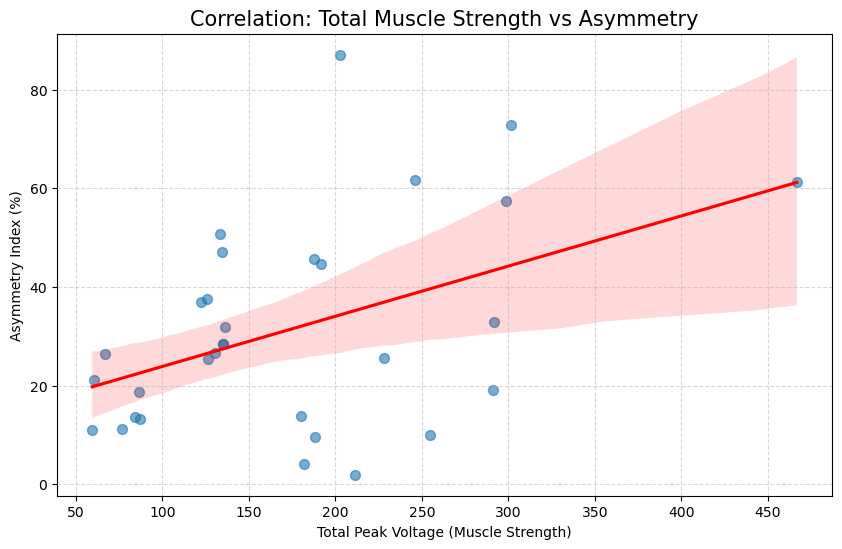

📊 근력과 비대칭의 상관계수: 0.44


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# 응 단골ㅎㅎㅎㅎㅎㅎㅎㅎㅎㅎ - 네, 얘네 없으면 수사 진행이 안 되죠! ㅋㅋㅋ

# -------------------------------------------------------------------------
# 1. '양쪽 힘의 합계' 컬럼 만들기 (전체적인 근력을 보기 위함)
# 💡 당황하지 않고 해석하는 법: "오른쪽 계산 결과를 왼쪽 이름(새 칸)에 집어넣어라!"
# LT(왼쪽) + RT(오른쪽)를 합쳐서 'Total_Peak'라는 통합 장부를 만드는 거예요.
# -------------------------------------------------------------------------
df_final['Total_Peak'] = df_final['LT_Peak'] + df_final['RT_Peak']

# -------------------------------------------------------------------------
# 2. 산점도(Scatter Plot) 및 회귀선(Regression Line) 그리기
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# regplot: 점을 찍는 산점도에 '회귀선'을 추가한 거예요.
# 💡 회귀선이 뭔데?: 데이터 점들 사이를 관통하는 '대표적인 추세선'이에요!
# 선이 아래로 내려가면 "한쪽이 커질 때 다른 쪽은 작아진다"는 경향을 한눈에 보여주죠.
# scatter_kws: 점(scatter)의 크기(s)랑 투명도(alpha) 조절
# line_kws: 회귀선의 색깔을 강렬한 빨간색으로!
sns.regplot(x='Total_Peak', y='Asymmetry', data=df_final, 
            scatter_kws={'s': 50, 'alpha': 0.6}, 
            line_kws={'color': 'red'})

# -------------------------------------------------------------------------
# 3. 그래프 꾸미기 (보고서 예쁘게 꾸며볼까 그뜻인)
# -------------------------------------------------------------------------
plt.title("Correlation: Total Muscle Strength vs Asymmetry", fontsize=15)
plt.xlabel("Total Peak Voltage (Muscle Strength)") # x축: 전체 근력
plt.ylabel("Asymmetry Index (%)")                 # y축: 비대칭 지수
plt.grid(True, linestyle='--', alpha=0.5)         # 배경에 모눈종이 깔기!

plt.show()

# -------------------------------------------------------------------------
# 4. 숫자(상관계수)로 확인 사살!
# -------------------------------------------------------------------------
correlation = df_final['Total_Peak'].corr(df_final['Asymmetry'])

# 💡 .2f 뭔데: "소수점 아래 두 자리(2)까지 실수(float) 형태로 보여줘!"라는 뜻이에요.
# 안 쓰면 0.12345678... 하고 지저분하게 나오니까 깔끔하게 이발해주는 거죠!
print(f"📊 근력과 비대칭의 상관계수: {correlation:.2f}")

In [34]:
# [실무] 고위험군 명단 추출 (근력도 세고 비대칭도 심한 사람)
# 분석 단계: 11단계 - 고위험군 타겟팅 (수사의 최종 목적지!)

# 1. 근력 상위 30% 커트라인 정하기
# quantile(0.7): "전체 인원 중 성적순으로 상위 30%가 시작되는 점수"를 찾아내라는 뜻!
threshold_peak = df_final['Total_Peak'].quantile(0.7) 

# 2. 긴 문장 당황하지 않고 읽는 법 (조건 필터링)
# 해석: df_final 장부에서 [전체 힘(Total_Peak)이 상위 30% 이상] 이고(&) 
# [비대칭(Asymmetry)이 50%를 넘는] 사람만 쏙 골라내서 'high_risk_group'에 담아라!
high_risk_group = df_final[(df_final['Total_Peak'] >= threshold_peak) & 
                           (df_final['Asymmetry'] > 50)] 

print("🚨 [보행 데이터 수사 결과] 고위험군 명단")

# 3. sort_values: 명단 정렬하기 (현경님이 아는 그 '정렬' 맞아요!)
# by='Asymmetry': "비대칭 점수"를 기준으로 줄을 세우겠다!
# ascending=False: "오름차순이 아니다(False)" 즉, 큰 놈부터 나오게 하는 '내림차순' 정렬!
# (거짓을 반환하는 게 아니라, "작은 순서대로(True) 할래?" 물음에 "아니(False), 큰 순서대로!"라고 답하는 거예요 ㅋㅋㅋ)
print(high_risk_group[['ID', 'Total_Peak', 'Asymmetry', 'Group_Tag']].sort_values(by='Asymmetry', ascending=False))

# 4. 수사관 현경의 한마디! (현경님이 분석 결과를 해석하기 편하게 넣어둔 거예요)
print(f"\n💡 총 {len(high_risk_group)}명의 피험자가 '강한 근력 + 심한 비대칭' 패턴을 보입니다.")
print("이분들은 보행 시 특정 근육의 보상 작용이 매우 강하므로, 부상 방지를 위한 자세 교정이 시급합니다.")

🚨 [보행 데이터 수사 결과] 고위험군 명단
     ID  Total_Peak  Asymmetry                   Group_Tag
0   S01  202.440755  87.060474  Group_A: Clinical_Disorder
18  S19  301.398662  72.775887  Group_A: Clinical_Disorder
13  S14  245.906023  61.745109       Group_B: Walking_Risk
29  S30  466.685756  61.305113       Group_B: Walking_Risk
11  S12  298.818660  57.456429       Group_B: Walking_Risk

💡 총 5명의 피험자가 '강한 근력 + 심한 비대칭' 패턴을 보입니다.
이분들은 보행 시 특정 근육의 보상 작용이 매우 강하므로, 부상 방지를 위한 자세 교정이 시급합니다.


In [35]:
# [실무] 고위험군 상세 진단 (분석 단계: 11.5단계 - 데이터 정규화 및 수치화)

# 1. 전체 피험자의 평균 Peak 값 계산
# .mean(): "평균(Mean) 내라!"는 명령어. 
# avg_lt: 모든 사람의 왼쪽 허벅지 평균 힘 / avg_rt: 오른쪽 평균 힘
avg_lt = df_final['LT_Peak'].mean() 
avg_rt = df_final['RT_Peak'].mean()

# 2. 고위험군만 따로 뽑아서 '독립된 새 장부'로 만들기 (경고 방지 핵심!)
# .copy(): "원본 장부 찢어오지 말고, 복사본 하나 새로 만들어!"라는 뜻.
# 이거 안 쓰면 나중에 "원본 장부에 낙서하는 거야?"라고 파이썬이 잔소리(Warning)해요. ㅋㅋㅋ
high_risk_group = df_final[(df_final['Total_Peak'] >= threshold_peak) & 
                           (df_final['Asymmetry'] > 50)].copy()

# 3. .loc을 사용하여 안전하게 계산값 대입
# .loc[:, 'LT_Status']: "모든 줄(:)의 'LT_Status'라는 칸에 다음 계산 결과를 박아라!"
# 계산식: 내 힘 / 남들 평균 (결과가 1.5면 남들보다 1.5배 더 힘을 쓰고 있다는 뜻!)
high_risk_group.loc[:, 'LT_Status'] = high_risk_group['LT_Peak'] / avg_lt
high_risk_group.loc[:, 'RT_Status'] = high_risk_group['RT_Peak'] / avg_rt

print("✅ 경고 없이 깔끔하게 계산 완료! (1.0 기준)") # 현경님 안심용 메시지!
# 요건 뭘 보여줄거냐 라는말: 
# "평균 대비 내 근육이 얼마나 열일(과활성)하고 있는지" 그 성적표를 보여주는 거예요.
print(high_risk_group[['ID', 'LT_Status', 'RT_Status']])


✅ 경고 없이 깔끔하게 계산 완료! (1.0 기준)
     ID  LT_Status  RT_Status
0   S01   0.629282   1.690391
11  S12   0.939351   2.484605
13  S14   1.343141   1.470902
18  S19   2.668690   0.773889
29  S30   3.732410   1.600622


In [36]:
# 중간에 컬럼명 뽑아보기
# 1. 현재 장부의 앞부분 5줄과 모든 이름표 확인
print("📋 현재 df_final의 컬럼명 리스트:")
print(df_final.columns.tolist())

print("\n🔍 데이터 미리보기 (상위 3행):")
display(df_final.head(3))

📋 현재 df_final의 컬럼명 리스트:
['semg LT TIB.A_mean_pct', 'semg LT TIB.A_peak_uv', 'semg RT TIB.A_mean_pct', 'semg RT TIB.A_peak_uv', 'semg LT REC.F_mean_pct', 'LT_Peak', 'semg RT REC.F_mean_pct', 'RT_Peak', 'semg LT HAM_mean_pct', 'semg LT HAM_peak_uv', 'semg RT HAM_mean_pct', 'semg RT HAM_peak_uv', 'Asymmetry', 'ID', 'Group_Tag', 'Total_Peak', 'Status']

🔍 데이터 미리보기 (상위 3행):


,semg LT TIB.A_mean_pct,semg LT TIB.A_peak_uv,semg RT TIB.A_mean_pct,semg RT TIB.A_peak_uv,semg LT REC.F_mean_pct,LT_Peak,semg RT REC.F_mean_pct,RT_Peak,semg LT HAM_mean_pct,semg LT HAM_peak_uv,semg RT HAM_mean_pct,semg RT HAM_peak_uv,Asymmetry,ID,Group_Tag,Total_Peak,Status
0,14.330132,163.131144,11.655848,333.217357,21.323769,55.172147,2.759195,147.268609,4.056316,183.291116,15.132736,49.198217,87.060474,S01,Group_A: Clinical_Disorder,202.440755,Potential_Risk
1,9.577239,222.244392,12.553693,175.494439,3.722003,128.514904,6.718348,62.886442,5.937350,54.203512,9.022633,39.090479,44.599430,S02,Group_B: Walking_Risk,191.401346,Potential_Risk
2,8.947362,176.734276,13.501059,130.934055,4.009510,81.276948,8.126132,51.737265,9.666859,58.080797,12.052898,36.742422,50.659053,S03,Group_B: Walking_Risk,133.014213,Potential_Risk


In [37]:
# 파일명에 날짜를 붙여두면 나중에 찾기 편해요! (2026-03-25 버전)
df_final.to_csv('Gait_Analysis_Result_Final.csv', index=False, encoding='utf-8-sig')

In [38]:
def load_and_clean_gait_data(file_path):
    # pd.read_csv: "파일 열어!" ---? 그런데 외 열까?
    df = pd.read_csv(file_path)
    
    # -------------------------------------------------------------------------
    # 1. 이름표 교체 (가방 먼저!) 
    # 💡 왜 했더라?: 
    # 원래 이름(semg LT TIB.A_peak_uv)이 너무 길어서 오타 나고 에러 났던 거 기억나시죠? ㅋㅋㅋ 
    # 'TIB_A_LT_Peak'처럼 짧고 강렬하게 불러야 우리가 안 헷갈리니까 바꾼 거예요!
    # -------------------------------------------------------------------------
    name_map = {
        'semg LT TIB.A_peak_uv': 'TIB_A_LT_Peak', # 앞정강근(TIB) 왼쪽 힘
        'semg RT TIB.A_peak_uv': 'TIB_A_RT_Peak', # 앞정강근(TIB) 오른쪽 힘
        'semg LT REC.F_peak_uv': 'REC_F_LT_Peak', # 허벅지 앞(REC) 왼쪽 힘
        'semg RT REC.F_peak_uv': 'REC_F_RT_Peak', # 허벅지 앞(REC) 오른쪽 힘
        'semg LT HAM_peak_uv': 'HAM_LT_Peak',     # 허벅지 뒤(HAM) 왼쪽 힘
        'semg RT HAM_peak_uv': 'HAM_RT_Peak'      # 허벅지 뒤(HAM) 오른쪽 힘
    }
    df.rename(columns=name_map, inplace=True)
    
    # -------------------------------------------------------------------------
    # 2. 비대칭도(Asymmetry) 계산
    # 💡 나 계산식 몰라ㅠㅠ: 
    # 쉽게 말하면 "양쪽 힘의 차이가 평균보다 얼마나 큰가?"를 %로 구하는 거예요.
    # 식: (왼쪽 - 오른쪽의 차이) / (둘의 평균값) * 100
    # 결과가 0%면 완벽 대칭! 100%면 한쪽만 힘쓰는 짝짝이!
    # -------------------------------------------------------------------------
    muscles = ['TIB_A', 'REC_F', 'HAM'] # 수사할 근육 3대장!
    for m in muscles:
        lt, rt = f'{m}_LT_Peak', f'{m}_RT_Peak'
        if lt in df.columns and rt in df.columns:
            # 절대값(abs)을 씌워서 누가 더 크든 상관없이 '차이'만 딱 구하기!
            df[f'{m}_Asym'] = (abs(df[lt] - df[rt]) / ((df[lt] + df[rt]) / 2) * 100)
            
    # -------------------------------------------------------------------------
    # 3. Status(평균 대비 활성도) 계산
    # 💡 요건 왜 계산했지?: 
    # "내가 남들보다 얼마나 열일하고 있나?" 성적표를 매기기 위해서예요!
    # 1.0 이면 딱 평균! 2.0 이면 남들보다 2배나 힘을 빡! 주고 있다는 증거죠.
    # -------------------------------------------------------------------------
    for m in muscles:
        lt, rt = f'{m}_LT_Peak', f'{m}_RT_Peak'
        if lt in df.columns:
            # 내 힘 / 모든 피험자의 평균 힘 = 나의 상대적 위치(Status)
            df[f'{m}_LT_Status'] = df[lt] / df[lt].mean()
            df[f'{m}_RT_Status'] = df[rt] / df[rt].mean()
            
    return df # 결과 반환!

In [39]:
# 내일 아침에 출근해서 이 한 줄만 딱 실행하면 수술 끝!
#df_final = load_and_clean_gait_data('raw_data.csv') 

# 잘 됐는지 확인용
#df_final.head()

In [40]:
# [실무] 근육 3형제(TIB.A, REC.F, HAM) 비대칭 전수조사
# 분석 단계: 12단계 - 다각도 정밀 진단 (근육별로 꼼꼼하게!)

# 💡 [공통 계산식 해설: 비대칭도(Asymmetry)]
# (abs(LT - RT)) / ((LT + RT) / 2) * 100
# 1. abs(LT - RT): "왼쪽/오른쪽 힘의 차이" (누가 크든 상관없이 벌어진 '거리'만 봐!)
# 2. / ((LT + RT) / 2): "두 힘의 평균값으로 나누기" (힘 센 사람, 약한 사람 공평하게 비교하려고!)
# 3. * 100: "퍼센트(%)로 변환" (그래야 20%인지 50%인지 한눈에 들어오니까!)

# 1. 허벅지 앞(REC.F - 대퇴직근) 비대칭도 계산
# [LT_Peak]와 [RT_Peak] 이름표를 사용해서 계산합니다!
df_final['REC_F_Asym'] = (abs(df_final['LT_Peak'] - df_final['RT_Peak']) / 
                          ((df_final['LT_Peak'] + df_final['RT_Peak']) / 2) * 100)

# 2. 앞정강근(TIB.A - 전경골근) 비대칭도 계산 
# (semg LT TIB.A_peak_uv: "왼쪽 종아리 앞쪽 힘!"이라고 읽으시면 됩니다 ㅋㅋㅋ)
df_final['TIB_A_Asym'] = (abs(df_final['semg LT TIB.A_peak_uv'] - df_final['semg RT TIB.A_peak_uv']) / 
                          ((df_final['semg LT TIB.A_peak_uv'] + df_final['semg RT TIB.A_peak_uv']) / 2) * 100)

# 3. 허벅지 뒤(HAM - 햄스트링) 비대칭도 계산
# (semg LT HAM_peak_uv: "왼쪽 허벅지 뒤쪽 힘!" 요것도 짝짝이 수사 시작!)
df_final['HAM_Asym'] = (abs(df_final['semg LT HAM_peak_uv'] - df_final['semg RT HAM_peak_uv']) / 
                        ((df_final['semg LT HAM_peak_uv'] + df_final['semg RT HAM_peak_uv']) / 2) * 100)

# 4. [진짜 전수조사] 3개 근육 비대칭 평균 내기 (최종 밸런스 점수!)
# .mean(axis=1): "한 사람의 [허벅지 앞, 종아리, 허벅지 뒤] 점수를 옆으로(가로) 싹 더해서 평균내라!"
df_final['Total_Asymmetry_Avg'] = df_final[['REC_F_Asym', 'TIB_A_Asym', 'HAM_Asym']].mean(axis=1)

print("✅ 근육 3형제(TIB.A, REC.F, HAM) 전수조사 완료!")

# 결과 확인: 가장 심각한(전체 평균 비대칭이 높은) 상위 5명 '내림차순' 검거!
# ascending=False: "큰 숫자(심각한 놈)부터 위로 올려줘!" (True면 낮은 순서!)
display(df_final[['ID', 'Total_Asymmetry_Avg', 'REC_F_Asym', 'TIB_A_Asym', 'HAM_Asym']].sort_values(by='Total_Asymmetry_Avg', ascending=False).head())

✅ 근육 3형제(TIB.A, REC.F, HAM) 전수조사 완료!


,ID,Total_Asymmetry_Avg,REC_F_Asym,TIB_A_Asym,HAM_Asym
0,S01,91.625036,90.986088,68.534996,115.354022
13,S14,84.084231,8.447917,198.230081,45.574694
11,S12,79.495309,89.756147,6.301845,142.427935
22,S23,74.877893,38.795069,77.331396,108.507215
18,S19,62.870894,110.521117,33.135490,44.956075


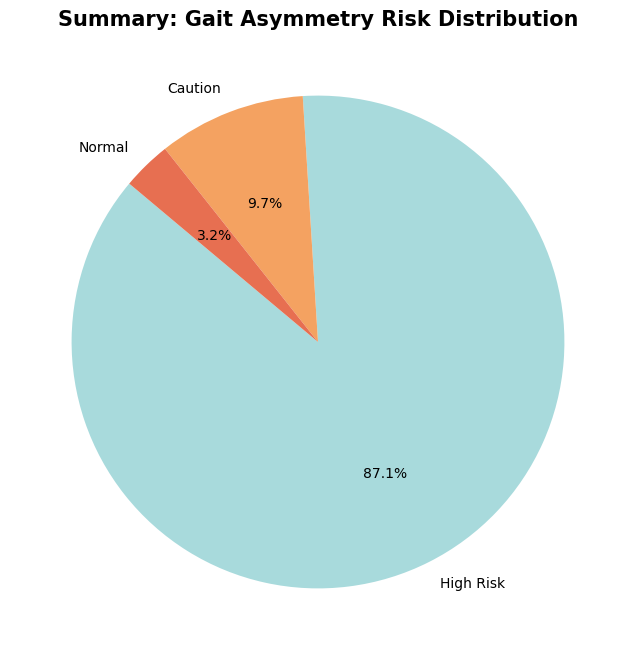

In [41]:
# [현경 수사대] 12단계 정밀 분석 후 '최종 요약' 단계
# 목적: 12단계의 복잡한 데이터를 3개의 핵심 그룹으로 묶어 시각화함

# 1. 12단계 데이터를 바탕으로 다시 크게 3그룹으로 리샘플링
# (0~10, 10~20, 20~100 구간은 12단계 중 각각 몇 단계씩을 포함하게 됨)
df_final['Risk_Level'] = pd.cut(df_final['Total_Asymmetry_Avg'], 
                                bins=[0, 10, 20, 100], 
                                labels=['Normal', 'Caution', 'High Risk'])

# 2. 그룹별 인원수 계산 (총 31명 중 비율 확인)
risk_counts = df_final['Risk_Level'].value_counts()

# 3. 원 그래프 사이즈 (8, 8) - 주피터에서 가장 차분하고 크게 보이는 사이즈!
plt.figure(figsize=(8, 8)) 

# 4. 그래프 그리기 (팀 프로젝트 발표용 최종 결과물)
plt.pie(risk_counts, 
        labels=risk_counts.index, 
        autopct='%1.1f%%', 
        colors=['#A8DADC', '#F4A261', '#E76F51'], # 너무 튀지 않는 '고민중독' 팀 컬러
        startangle=140)

plt.title("Summary: Gait Asymmetry Risk Distribution", fontsize=15, fontweight='bold')
plt.show()

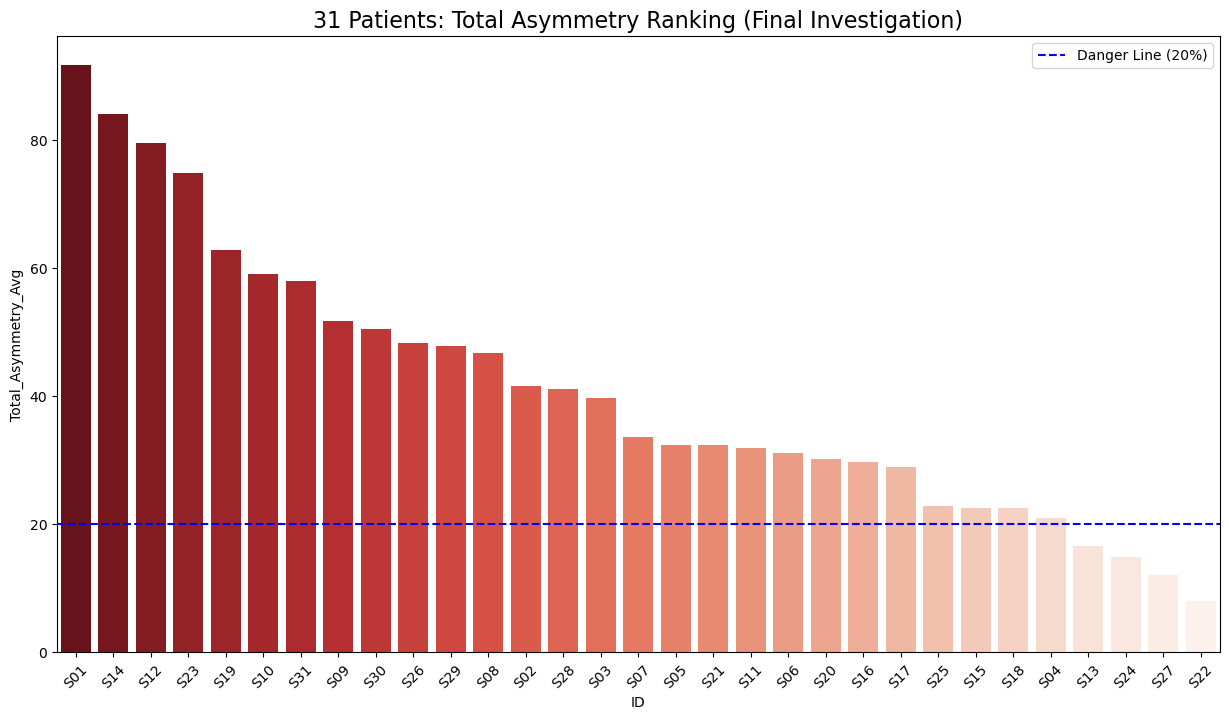

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 판 크기 조절 (15:8 비율 - 31명이니까 가로로 길게 빼야 안 겹쳐요!)
plt.figure(figsize=(15, 8))

# 2. 31명 랭킹 세우기 (데이터 정렬 및 시각화)
# data=df_final.sort_values(...): '비대칭 평균'이 높은 순서(내림차순)로 데이터를 줄 세웁니다.
# hue='ID': 각 막대마다 ID를 기준으로 색상을 할당 (최신 라이브러리 경고 방지용)
# palette='Reds_r': 위험한 사람일수록 진한 빨간색으로 칠해주는 '빨간 맛' 그라데이션!
# legend=False: 31명의 이름표가 그래프를 가리지 않게 숨깁니다.
sns.barplot(x='ID', y='Total_Asymmetry_Avg', 
            data=df_final.sort_values('Total_Asymmetry_Avg', ascending=False), 
            hue='ID', palette='Reds_r', legend=False)

# 3. 위험 기준선 긋기 (물리치료 임상 기준 20% 지점)
# axhline: 가로(Horizontal)로 선을 긋는 함수 (y=20 지점에 파란 점선)
plt.axhline(y=20, color='blue', linestyle='--', label='Danger Line (20%)')

# 4. 차트 마무리 (제목 및 라벨 정리)
plt.title("31 Patients: Total Asymmetry Ranking (Final Investigation)", fontsize=16)
plt.xticks(rotation=45) # ID가 겹치지 않게 45도 기울여서 표시
plt.legend()             # Danger Line의 이름표를 표시
plt.show()               # 최종 결과물 

In [43]:
# [진짜 마지막] 수사 결과 엑셀로 뽑기 (이거 파일로 드려야 치료사님이 보시겠죠?)
# 20% 넘는 위험군만 따로 모아서 저장하기
high_risk_list = df_final[df_final['Total_Asymmetry_Avg'] > 20].sort_values(by='Total_Asymmetry_Avg', ascending=False)

high_risk_list.to_excel('High_Risk_Patients_List.xlsx', index=False)
print("💾 고위험군 명단 엑셀 파일 생성 완료!")

💾 고위험군 명단 엑셀 파일 생성 완료!


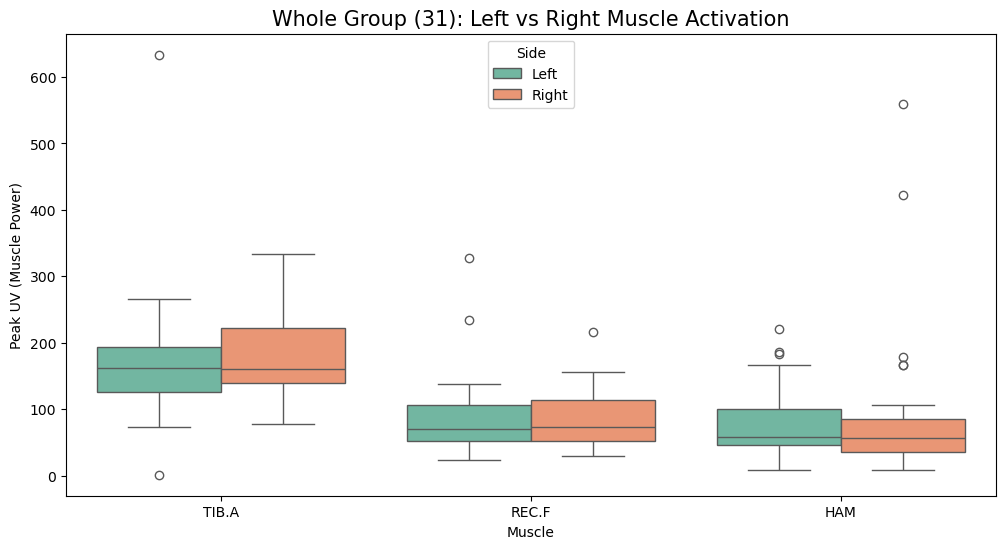

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 근육 데이터를 '한 바구니(plot_data)'에 담기
# df_final의 가로 데이터를 세로로 길게 펴야 그래프 그리기가 편함
plot_data = []

for _, row in df_final.iterrows():
    # TIB.A (전경골근 - 정강이 근육) 좌우 
    plot_data.append({'ID': row['ID'], 'Muscle': 'TIB.A', 'Side': 'Left', 'Value': row['semg LT TIB.A_peak_uv']})
    plot_data.append({'ID': row['ID'], 'Muscle': 'TIB.A', 'Side': 'Right', 'Value': row['semg RT TIB.A_peak_uv']})
    
    # REC.F (대퇴직근 - 허벅지 앞쪽) 좌우  (현경님이 줄인 이름표!)
    plot_data.append({'ID': row['ID'], 'Muscle': 'REC.F', 'Side': 'Left', 'Value': row['LT_Peak']})
    plot_data.append({'ID': row['ID'], 'Muscle': 'REC.F', 'Side': 'Right', 'Value': row['RT_Peak']})
    
    # HAM (햄스트링 - 허벅지 뒤쪽) 좌우 
    plot_data.append({'ID': row['ID'], 'Muscle': 'HAM', 'Side': 'Left', 'Value': row['semg LT HAM_peak_uv']})
    plot_data.append({'ID': row['ID'], 'Muscle': 'HAM', 'Side': 'Right', 'Value': row['semg RT HAM_peak_uv']})

# 데이터프레임으로 변환
df_plot = pd.DataFrame(plot_data)

# 2. 박스플롯(Boxplot) 그리기 (근육별 좌우 파워 비교)
# figsize=(12, 6): 가로로 길게 빼서 세 근육(TIB, REC, HAM)을 한눈에!
plt.figure(figsize=(12, 6))

# sns.boxplot: 데이터의 중앙값, 튀는 값(이상치)을 한눈에 보여주는 최고의 도구
# hue='Side': 왼쪽(Left)과 오른쪽(Right)을 색깔로 구분해서 비교
sns.boxplot(x='Muscle', y='Value', hue='Side', data=df_plot, palette='Set2')

plt.title("Whole Group (31): Left vs Right Muscle Activation", fontsize=15)
plt.ylabel("Peak UV (Muscle Power)") # 근육이 내는 힘(전압) 단위
plt.show()

In [45]:
#1단계: 함수 정의된 셀(그 수술 로봇 껍데기 있는 곳) 실행!

#2단계: df_final = load_and_clean_gait_data('raw_data.csv') 실행!

#3단계: 오늘 변수명 고생해서 만든 그래프 셀들 쭈르륵 실행!